In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
import warnings
import scienceplots
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Publication style (consistent across all notebooks) ──────────
plt.style.use(['science', 'ieee', 'no-latex'])
sns.set_style("whitegrid", {'grid.alpha': 0.25, 'grid.linewidth': 0.4})

COL_W = 3.5
PAGE_W = 7.2
GOLDEN = 1.618

FIGURES_DIR = Path('/data/jane/convert/math_gender/conversion_test/2_analysis/figures')
FIGURES_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'lines.markersize': 5,
})

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f'{name}.pdf')
    fig.savefig(FIGURES_DIR / f'{name}.png', dpi=300)
    print(f'  → saved {name}.pdf / .png')

rng = np.random.default_rng(42)
N_BOOT = 10_000

def bootstrap_ci_mean(series, n_boot=N_BOOT, ci=95):
    """Percentile bootstrap CI for the sample mean."""
    vals = np.asarray(series, dtype=float)
    n = len(vals)
    if n == 0:
        return (0.0, 0.0)
    boot_means = np.array([vals[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)])
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lo, hi

ERR_KW = dict(elinewidth=1.0, capsize=3, capthick=0.8, ecolor='#333333')

CB_PALETTE = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
              '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']

COND_COLORS = {'math_only': '#332288', 'in_domain_no_guide': '#44AA99', 'in_domain_with_guide': '#CC6677'}
COND_LABELS = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}
COND_ORDER = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']

MODEL_PALETTE = {
    'gpt-4o': '#332288', 'qwen-coder': '#88CCEE', 'llama-4': '#44AA99',
    'gpt-oss-120b': '#117733', 'gpt-5.2': '#CC6677', 'deepseek-v3.1': '#999933',
    'claude-haiku-4-5': '#882255', 'qwen3-235b-thinking': '#DDCC77',
}

COST_PER_MTOK = {
    'gpt-5.2': 14.00, 'gpt-4o': 10.00, 'claude-haiku-4-5': 5.00,
    'gpt-oss-120b': 0.60, 'deepseek-v3.1': 1.70, 'qwen-coder': 2.00,
    'qwen3-235b-thinking': 3.00, 'llama-4': 0.85,
}

NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'claude-haiku-4-5']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5 ★',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

In [2]:
df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv',
                 sep='\t', low_memory=False)

df['reasoning_tokens'] = pd.to_numeric(df['reasoning_tokens'], errors='coerce').fillna(0)
df['response_len'] = df['raw_response'].astype(str).str.len()
df['est_output_tokens'] = df['response_len'] / 4.0

df['output_tokens'] = np.where(
    df['reasoning_tokens'] > 0,
    df['reasoning_tokens'] + df['est_output_tokens'],
    df['est_output_tokens']
)

df['cost_per_mtok'] = df['model'].map(COST_PER_MTOK)
df['cost_usd'] = df['output_tokens'] * df['cost_per_mtok'] / 1_000_000

df['is_correct'] = df['loss'] == 0

print(f"Loaded {len(df):,} rows, {df['model'].nunique()} models")
print(f"\nOutput token stats per model:")
print(df.groupby('model')['output_tokens'].agg(['mean', 'median', 'std']).round(1).to_string())
print(f"\nCost per entry (USD) by model:")
print(df.groupby('model')['cost_usd'].agg(['mean', 'median', 'sum']).rename(
    columns={'mean': 'mean_$', 'median': 'median_$', 'sum': 'total_$'}).to_string())

Loaded 3,182,736 rows, 8 models

Output token stats per model:
                       mean  median     std
model                                      
claude-haiku-4-5      664.0   565.8   521.9
deepseek-v3.1          15.8     5.8   206.2
gpt-4o                  8.3     5.8    16.9
gpt-5.2               155.7     8.0   347.6
gpt-oss-120b            5.6     5.8     2.0
llama-4                93.9    29.5   126.1
qwen-coder              9.8     5.8    28.1
qwen3-235b-thinking  1783.8  1063.5  1826.1

Cost per entry (USD) by model:
                       mean_$  median_$      total_$
model                                               
claude-haiku-4-5     0.003320  0.002829   802.271431
deepseek-v3.1        0.000027  0.000010    10.955660
gpt-4o               0.000083  0.000058    39.084108
gpt-5.2              0.002179  0.000112  1025.364337
gpt-oss-120b         0.000003  0.000003     0.807548
llama-4              0.000080  0.000025    37.560552
qwen-coder           0.000020  0.000012  

=== Cost by Model ===
                         n mean_tokens median_tokens  mean_cost median_cost total_cost accuracy_% cost_per_correct
model                                                                                                             
Qwen3-235B-Think ★  408702        1784          1064  $0.005351   $0.003191   $2187.14      92.5%        $0.005786
Claude-Haiku-4.5 ★  241662         664           566  $0.003320   $0.002829    $802.27      84.1%        $0.003949
GPT-5.2 ★           470502         156             8  $0.002179   $0.000112   $1025.36      88.3%        $0.002467
GPT-4o              470502           8             6  $0.000083   $0.000058     $39.08      76.6%        $0.000108
Llama-4-Maverick    470502          94            30  $0.000080   $0.000025     $37.56      78.5%        $0.000102
DeepSeek-V3.1 ★     408702          16             6  $0.000027   $0.000010     $10.96      81.3%        $0.000033
Qwen3-Coder-480B    470502          10             6  $0.0

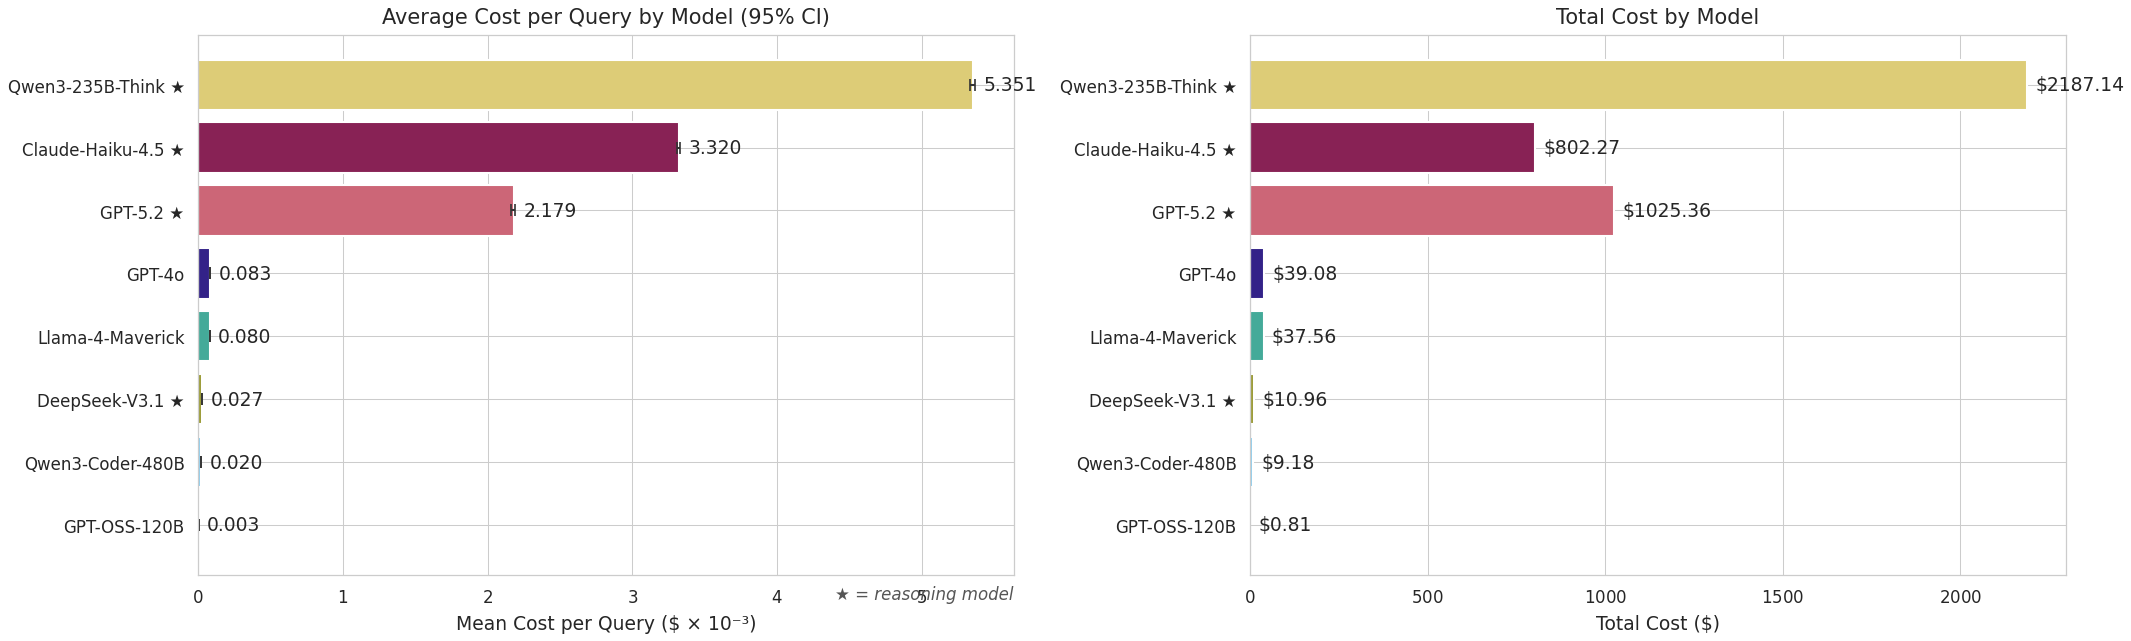

In [3]:
# ── 1. Cost by Model ──

model_cost = (
    df.groupby('model')
    .agg(
        n=('cost_usd', 'size'),
        mean_tokens=('output_tokens', 'mean'),
        median_tokens=('output_tokens', 'median'),
        mean_cost=('cost_usd', 'mean'),
        median_cost=('cost_usd', 'median'),
        total_cost=('cost_usd', 'sum'),
        accuracy=('is_correct', 'mean'),
    )
)
model_cost['accuracy_%'] = model_cost['accuracy'] * 100
model_cost['cost_per_correct'] = model_cost['total_cost'] / (model_cost['accuracy'] * model_cost['n'])
model_cost = model_cost.sort_values('mean_cost', ascending=False)

print("=== Cost by Model ===")
fmt_cols = {'mean_tokens': '{:.0f}', 'median_tokens': '{:.0f}',
            'mean_cost': '${:.6f}', 'median_cost': '${:.6f}',
            'total_cost': '${:.2f}', 'accuracy_%': '{:.1f}%',
            'cost_per_correct': '${:.6f}'}
display_df = model_cost.drop(columns=['accuracy']).copy()
for col, f in fmt_cols.items():
    if col in display_df.columns:
        display_df[col] = display_df[col].map(lambda v, f=f: f.format(v))
display_df.index = display_df.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(display_df.to_string())

# Bar chart: mean cost per query by model
fig, axes = plt.subplots(1, 2, figsize=(PAGE_W * 2, PAGE_W / GOLDEN))

order = model_cost.index.tolist()
colors = [MODEL_PALETTE.get(m, CB_PALETTE[i % len(CB_PALETTE)]) for i, m in enumerate(order)]

ax = axes[0]
mean_vals = model_cost['mean_cost'].values * 1000
ci_data = [bootstrap_ci_mean(df[df['model'] == m]['cost_usd']) for m in order]
xerr_lo = mean_vals - np.array([lo * 1000 for lo, hi in ci_data])
xerr_hi = np.array([hi * 1000 for lo, hi in ci_data]) - mean_vals
bars = ax.barh([MODEL_DISPLAY.get(m, m) for m in order],
               mean_vals, color=colors, edgecolor='white',
               xerr=[xerr_lo, xerr_hi], error_kw=ERR_KW)
ax.set_xlabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_title('Average Cost per Query by Model (95% CI)')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)

ax = axes[1]
bars = ax.barh([MODEL_DISPLAY.get(m, m) for m in order],
               model_cost['total_cost'], color=colors, edgecolor='white')
ax.set_xlabel('Total Cost ($)')
ax.set_title('Total Cost by Model')
ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9)

for ax in axes:
    ax.invert_yaxis()

axes[0].annotate('★ = reasoning model', xy=(1.0, -0.02), xycoords='axes fraction',
                 fontsize=8, va='top', ha='right', style='italic', color='#555555')
plt.tight_layout()
plt.show()

=== Mean Cost per Query ($) by Model × Condition ===
condition           in_domain_no_guide  in_domain_with_guide  math_only
model                                                                  
Claude-Haiku-4.5 ★              2.9912                3.9174     1.8549
DeepSeek-V3.1 ★                 0.0175                0.0377     0.0218
GPT-4o                          0.0808                0.0607     0.2020
GPT-5.2 ★                       0.7090                3.7640     2.2713
GPT-OSS-120B                    0.0035                0.0031     0.0035
Llama-4-Maverick                0.0433                0.1254     0.0526
Qwen3-Coder-480B                0.0165                0.0221     0.0228
Qwen3-235B-Think ★              4.9587                6.0676     3.0000
(values in $ × 10⁻³)

=== Mean Output Tokens by Model × Condition ===
condition           in_domain_no_guide  in_domain_with_guide  math_only
model                                                                  
Claude-Haiku-

/tmp/ipykernel_2896302/3767659347.py:99: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect_patch, connectors = ax.indicate_inset_zoom(ax_ins, edgecolor='grey', alpha=0.5, lw=0.8)
/tmp/ipykernel_2896302/3767659347.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


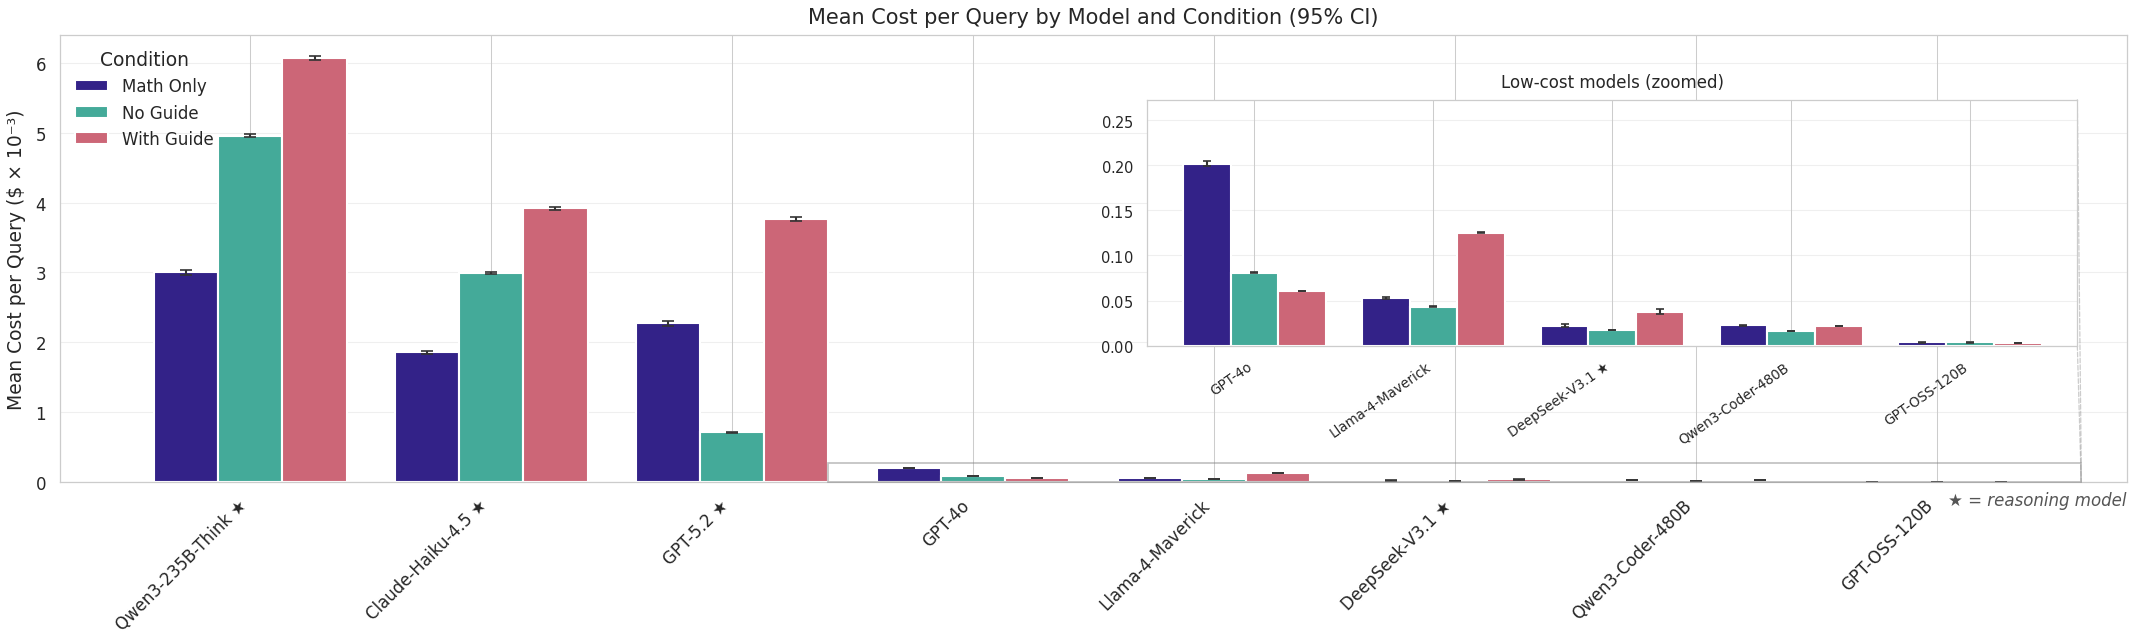

In [4]:
# ── 2. Cost by Condition ──

cond_cost = (
    df.groupby(['model', 'condition'])
    .agg(mean_tokens=('output_tokens', 'mean'),
         mean_cost=('cost_usd', 'mean'),
         total_cost=('cost_usd', 'sum'),
         accuracy=('is_correct', 'mean'))
    .reset_index()
)
cond_cost['accuracy_%'] = cond_cost['accuracy'] * 100

print("=== Mean Cost per Query ($) by Model × Condition ===")
pivot_cost = cond_cost.pivot(index='model', columns='condition', values='mean_cost').mul(1000)
pivot_cost.index = pivot_cost.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(pivot_cost.round(4).to_string())
print("(values in $ × 10⁻³)")

print("\n=== Mean Output Tokens by Model × Condition ===")
pivot_tok = cond_cost.pivot(index='model', columns='condition', values='mean_tokens')
pivot_tok.index = pivot_tok.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(pivot_tok.round(0).astype(int).to_string())

# Grouped bar chart: cost by model, hue = condition
cond_order = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']
cond_labels = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

models_sorted = list(cond_cost.groupby('model')['mean_cost'].mean().sort_values(ascending=False).index)
low_cost_models = {'gpt-4o', 'llama-4', 'deepseek-v3.1', 'qwen-coder', 'gpt-oss-120b'}
low_cost_indices = [i for i, m in enumerate(models_sorted) if m in low_cost_models]

n_c = len(cond_order)
palette = [COND_COLORS[c] for c in cond_order]

fig, ax = plt.subplots(figsize=(PAGE_W * 2, PAGE_W / GOLDEN))

n_m = len(models_sorted)
bw = 0.8 / n_c
x = np.arange(n_m)

all_vals = {}
all_yerr = {}
for j, cond in enumerate(cond_order):
    vals, yerr_lo, yerr_hi = [], [], []
    for m in models_sorted:
        row = cond_cost[(cond_cost['model'] == m) & (cond_cost['condition'] == cond)]
        v = row['mean_cost'].values[0] * 1000 if len(row) else 0
        vals.append(v)
        sub = df[(df['model'] == m) & (df['condition'] == cond)]['cost_usd']
        lo, hi = bootstrap_ci_mean(sub)
        yerr_lo.append(v - lo * 1000)
        yerr_hi.append(hi * 1000 - v)
    offsets = x + (j - (n_c - 1) / 2) * bw
    ax.bar(offsets, vals, bw, label=cond_labels[cond], color=palette[j], edgecolor='white',
           yerr=[yerr_lo, yerr_hi], error_kw=ERR_KW)
    all_vals[cond] = vals
    all_yerr[cond] = (yerr_lo, yerr_hi)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in models_sorted], rotation=45, ha='right')
ax.set_ylabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_title('Mean Cost per Query by Model and Condition (95% CI)')
ax.legend(title='Condition', loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.annotate('★ = reasoning model', xy=(1.0, -0.02), xycoords='axes fraction',
            fontsize=8, va='top', ha='right', style='italic', color='#555555')

# Inset axes zooming into the low-cost models
ax_ins = inset_axes(ax, width="45%", height="55%", loc='center right',
                    bbox_to_anchor=(-0.02, 0.08, 1.0, 1.0), bbox_transform=ax.transAxes)

zoom_x_min = min(low_cost_indices) - 0.6
zoom_x_max = max(low_cost_indices) + 0.6
zoom_vals = [v for i, v in enumerate(all_vals[cond_order[0]]) if i in low_cost_indices]
for cond in cond_order:
    zoom_vals.extend(v for i, v in enumerate(all_vals[cond]) if i in low_cost_indices)
zoom_y_max = max(zoom_vals) * 1.35

for j, cond in enumerate(cond_order):
    vals = all_vals[cond]
    yerr_lo, yerr_hi = all_yerr[cond]
    offsets = x + (j - (n_c - 1) / 2) * bw
    ax_ins.bar(offsets, vals, bw, color=palette[j], edgecolor='white',
               yerr=[yerr_lo, yerr_hi], error_kw={**ERR_KW, 'capsize': 2})

ax_ins.set_xlim(zoom_x_min, zoom_x_max)
ax_ins.set_ylim(0, zoom_y_max)
ax_ins.set_xticks([i for i in range(n_m) if i in low_cost_indices])
ax_ins.set_xticklabels([MODEL_DISPLAY.get(models_sorted[i], models_sorted[i])
                         for i in range(n_m) if i in low_cost_indices],
                        rotation=35, ha='right', fontsize=6.5)
ax_ins.tick_params(axis='y', labelsize=7)
ax_ins.set_title('Low-cost models (zoomed)', fontsize=8)
ax_ins.grid(axis='y', alpha=0.3)

# Draw connector lines from the zoomed region to the inset
rect_patch, connectors = ax.indicate_inset_zoom(ax_ins, edgecolor='grey', alpha=0.5, lw=0.8)
for c in connectors:
    c.set(linestyle='--', alpha=0.4, lw=0.6)

plt.tight_layout()
plt.show()

  → saved pyramid_accuracy_vs_cost.pdf / .png


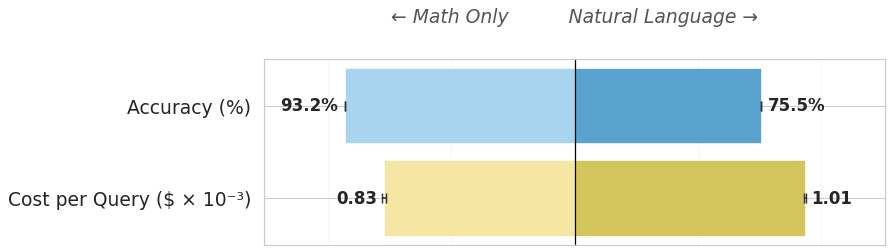

Accuracy: Math Only = 93.2% 95% CI [93.1, 93.3]
          No Guide  = 75.5% 95% CI [75.4, 75.6]
          permutation p = 0.0000 ***
Cost:     Math Only = 0.835 95% CI [0.827, 0.843]
          No Guide  = 1.007 95% CI [1.002, 1.011]
          permutation p = 0.0000 ***
(cost in $ × 10⁻³ per query)


In [7]:
# ── Pyramid: Math Only vs No Guide — Averaged Accuracy & Cost ────
# Single axis with accuracy (top row) and cost (bottom row).
# Cost bars rescaled visually; bootstrap CIs + permutation p-values shown.

from matplotlib.patches import Patch

_df_math = df[df['condition'] == 'math_only']
_df_ng   = df[df['condition'] == 'in_domain_no_guide']

avg_acc_math  = _df_math['is_correct'].mean() * 100
avg_acc_ng    = _df_ng['is_correct'].mean() * 100
avg_cost_math = _df_math['cost_usd'].mean() * 1000
avg_cost_ng   = _df_ng['cost_usd'].mean() * 1000

# Bootstrap CIs (on per-query data)
ci_acc_math  = tuple(v * 100 for v in bootstrap_ci_mean(_df_math['is_correct']))
ci_acc_ng    = tuple(v * 100 for v in bootstrap_ci_mean(_df_ng['is_correct']))
ci_cost_math = tuple(v * 1000 for v in bootstrap_ci_mean(_df_math['cost_usd']))
ci_cost_ng   = tuple(v * 1000 for v in bootstrap_ci_mean(_df_ng['cost_usd']))

# Permutation test for difference in means
def perm_test(a, b, n_perm=N_BOOT):
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = abs(a.mean() - b.mean())
    pooled = np.concatenate([a, b])
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        count += abs(perm[:len(a)].mean() - perm[len(a):].mean()) >= obs
    return count / n_perm

p_acc  = perm_test(_df_math['is_correct'], _df_ng['is_correct'])
p_cost = perm_test(_df_math['cost_usd'],   _df_ng['cost_usd'])

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

# Scale cost into accuracy-% space so both rows look proportional
cost_scale = max(avg_acc_math, avg_acc_ng) / max(avg_cost_math, avg_cost_ng)
scaled_cost_math = avg_cost_math * cost_scale
scaled_cost_ng   = avg_cost_ng   * cost_scale

# Colors: light blue for accuracy, light yellow for cost; darker for No Guide side
ACC_MATH = '#a8d4f0'   # light blue
ACC_NG   = '#5ba3cf'   # darker blue
COST_MATH = '#f5e6a3'  # light yellow
COST_NG   = '#d4c45c'  # darker yellow

fig, ax = plt.subplots(figsize=(PAGE_W * 0.85, PAGE_W * 0.28))

y_acc, y_cost = 0.55, 0
h = 0.45

# Error bar styling
err_kw = dict(elinewidth=0.8, capsize=2.5, capthick=0.7, ecolor='#333333')

ax.barh(y_acc, -avg_acc_math, height=h,
        color=ACC_MATH, edgecolor='white', linewidth=0.3)
ax.barh(y_acc, avg_acc_ng, height=h,
        color=ACC_NG, edgecolor='white', linewidth=0.3)

sc_err_math = [[(avg_cost_math - ci_cost_math[0]) * cost_scale],
               [(ci_cost_math[1] - avg_cost_math) * cost_scale]]
sc_err_ng   = [[(avg_cost_ng - ci_cost_ng[0]) * cost_scale],
               [(ci_cost_ng[1] - avg_cost_ng) * cost_scale]]

ax.barh(y_cost, -scaled_cost_math, height=h,
        color=COST_MATH, edgecolor='white', linewidth=0.3)
ax.barh(y_cost, scaled_cost_ng, height=h,
        color=COST_NG, edgecolor='white', linewidth=0.3)

# Draw error bars separately
ax.errorbar(-avg_acc_math, y_acc,
            xerr=[[avg_acc_math - ci_acc_math[0]], [ci_acc_math[1] - avg_acc_math]],
            fmt='none', **err_kw)
ax.errorbar(avg_acc_ng, y_acc,
            xerr=[[avg_acc_ng - ci_acc_ng[0]], [ci_acc_ng[1] - avg_acc_ng]],
            fmt='none', **err_kw)
ax.errorbar(-scaled_cost_math, y_cost, xerr=sc_err_math, fmt='none', **err_kw)
ax.errorbar(scaled_cost_ng, y_cost, xerr=sc_err_ng, fmt='none', **err_kw)

pad = max(avg_acc_math, avg_acc_ng) * 0.03

ax.text(-avg_acc_math - pad, y_acc, f'{avg_acc_math:.1f}%',
        ha='right', va='center', fontsize=8, fontweight='bold')
ax.text(avg_acc_ng + pad, y_acc, f'{avg_acc_ng:.1f}%',
        ha='left', va='center', fontsize=8, fontweight='bold')

ax.text(-scaled_cost_math - pad, y_cost, f'{avg_cost_math:.2f}',
        ha='right', va='center', fontsize=8, fontweight='bold')
ax.text(scaled_cost_ng + pad, y_cost, f'{avg_cost_ng:.2f}',
        ha='left', va='center', fontsize=8, fontweight='bold')

xmax = max(avg_acc_math, avg_acc_ng) * 1.35
ax.set_xlim(-xmax, xmax)
ax.set_yticks([y_cost, y_acc])
ax.set_yticklabels(['Cost per Query ($ × 10⁻³)', 'Accuracy (%)'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.6)
ax.grid(axis='x', alpha=0.15)
ax.set_xticklabels([])
ax.tick_params(axis='x', length=0)


# ax.legend(
#     handles=[Patch(color=COND_COLORS['math_only'], label='Math Only'),
#              Patch(color=COND_COLORS['in_domain_no_guide'], label='Natural Language')],
#     loc='upper center', ncol=2, fontsize=8, frameon=True,
#     edgecolor='#cccccc', bbox_to_anchor=(0.5, 1.32)
# )
ax.set_title('← Math Only          Natural Language →', fontsize=9,
             style='italic', color='#555', pad=18)

plt.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, 'pyramid_accuracy_vs_cost')
plt.show()

print(f'Accuracy: Math Only = {avg_acc_math:.1f}% 95% CI [{ci_acc_math[0]:.1f}, {ci_acc_math[1]:.1f}]')
print(f'          No Guide  = {avg_acc_ng:.1f}% 95% CI [{ci_acc_ng[0]:.1f}, {ci_acc_ng[1]:.1f}]')
print(f'          permutation p = {p_acc:.4f} {sig_stars(p_acc)}')
print(f'Cost:     Math Only = {avg_cost_math:.3f} 95% CI [{ci_cost_math[0]:.3f}, {ci_cost_math[1]:.3f}]')
print(f'          No Guide  = {avg_cost_ng:.3f} 95% CI [{ci_cost_ng[0]:.3f}, {ci_cost_ng[1]:.3f}]')
print(f'          permutation p = {p_cost:.4f} {sig_stars(p_cost)}')
print('(cost in $ × 10⁻³ per query)')

  → saved cost_latency_reasoning_correlation.pdf / .png


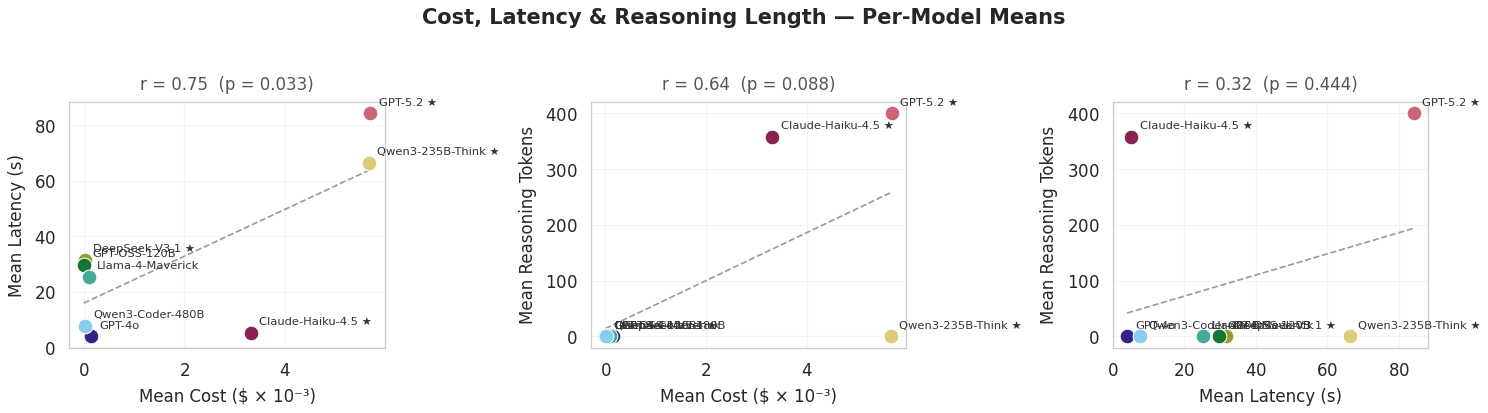


Per-model means:
             Model  Cost ($×10⁻³)  Latency (s)  Reason Tok
Claude-Haiku-4.5 ★           3.32         5.18      357.33
   DeepSeek-V3.1 ★           0.03        31.68        0.00
            GPT-4o           0.15         3.97        0.00
         GPT-5.2 ★           5.70        84.24      399.84
      GPT-OSS-120B           0.00        29.68        0.00
  Llama-4-Maverick           0.10        25.33        0.00
  Qwen3-Coder-480B           0.02         7.68        0.00
Qwen3-235B-Think ★           5.67        66.40        0.00


In [8]:
# ── Correlation: Cost, Latency, and Reasoning Length ─────────────
# Scatter-matrix of per-model means for cost_usd, call_seconds, and
# reasoning_tokens, colored by model.

from scipy import stats as sp_stats

df_corr = df[df['call_seconds'].notna() & (df['output_tokens'] > 0)].copy()

model_means = (
    df_corr.groupby('model')
    .agg(
        cost_usd=('cost_usd', 'mean'),
        call_seconds=('call_seconds', 'mean'),
        reasoning_tokens=('reasoning_tokens', 'mean'),
        output_tokens=('output_tokens', 'mean'),
    )
    .reset_index()
)
model_means['display'] = model_means['model'].map(MODEL_DISPLAY)
model_means['cost_millicents'] = model_means['cost_usd'] * 1000

metrics = [
    ('cost_millicents',   'Mean Cost ($ × 10⁻³)'),
    ('call_seconds',      'Mean Latency (s)'),
    ('reasoning_tokens',  'Mean Reasoning Tokens'),
]

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W * 1.4, PAGE_W * 0.38))

pairs = [
    (0, 1),  # cost vs latency
    (0, 2),  # cost vs reasoning tokens
    (1, 2),  # latency vs reasoning tokens
]

for ax, (i, j) in zip(axes, pairs):
    xcol, xlabel = metrics[i]
    ycol, ylabel = metrics[j]
    for _, row in model_means.iterrows():
        c = MODEL_PALETTE.get(row['model'], '#888888')
        ax.scatter(row[xcol], row[ycol], color=c, s=50, zorder=3, edgecolors='white', linewidth=0.5)
        ax.annotate(row['display'], (row[xcol], row[ycol]),
                    fontsize=5.5, ha='left', va='bottom',
                    xytext=(4, 3), textcoords='offset points', color='#333')

    x = model_means[xcol].values
    y = model_means[ycol].values
    r, p = sp_stats.pearsonr(x, y)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(f'r = {r:.2f}  (p = {p:.3f})', fontsize=8, color='#555')
    ax.grid(alpha=0.2)

    if len(x) > 2 and abs(r) > 0.3:
        z = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 50)
        ax.plot(xline, np.polyval(z, xline), '--', color='#999', linewidth=0.8, zorder=1)

fig.suptitle('Cost, Latency & Reasoning Length — Per-Model Means', fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'cost_latency_reasoning_correlation')
plt.show()

print('\nPer-model means:')
print(model_means[['display', 'cost_millicents', 'call_seconds', 'reasoning_tokens']].rename(
    columns={'display': 'Model', 'cost_millicents': 'Cost ($×10⁻³)',
             'call_seconds': 'Latency (s)', 'reasoning_tokens': 'Reason Tok'}
).to_string(index=False, float_format='%.2f'))

=== Mean Cost per Query ($×10⁻³) by Model × Domain ===
domain              currency  energy  volume  density  moles_to_particles  timezone   speed  cooking  bits_bytes  temperature  clothing_size
model                                                                                                                                       
Qwen3-235B-Think ★    6.6642  5.9642  5.7119   5.7637              7.2262    2.9537  4.7335   4.2414      3.2852       2.8321         1.1819
Claude-Haiku-4.5 ★    3.4458  3.5093  2.9419   5.4013              3.3794    3.0116  2.0977   1.4912      2.3576       1.3173         2.3690
GPT-5.2 ★             5.2867  3.6179  2.6056   0.0998              0.1128    1.4468  0.0953   0.0883      0.0878       0.3002         0.0687
GPT-4o                0.0590  0.0388  0.0619   0.0585              0.0491    0.5457  0.0461   0.0377      0.0459       0.0460         0.0254
Llama-4-Maverick      0.0744  0.0812  0.0662   0.0946              0.1243    0.1375  0.0387   0.046

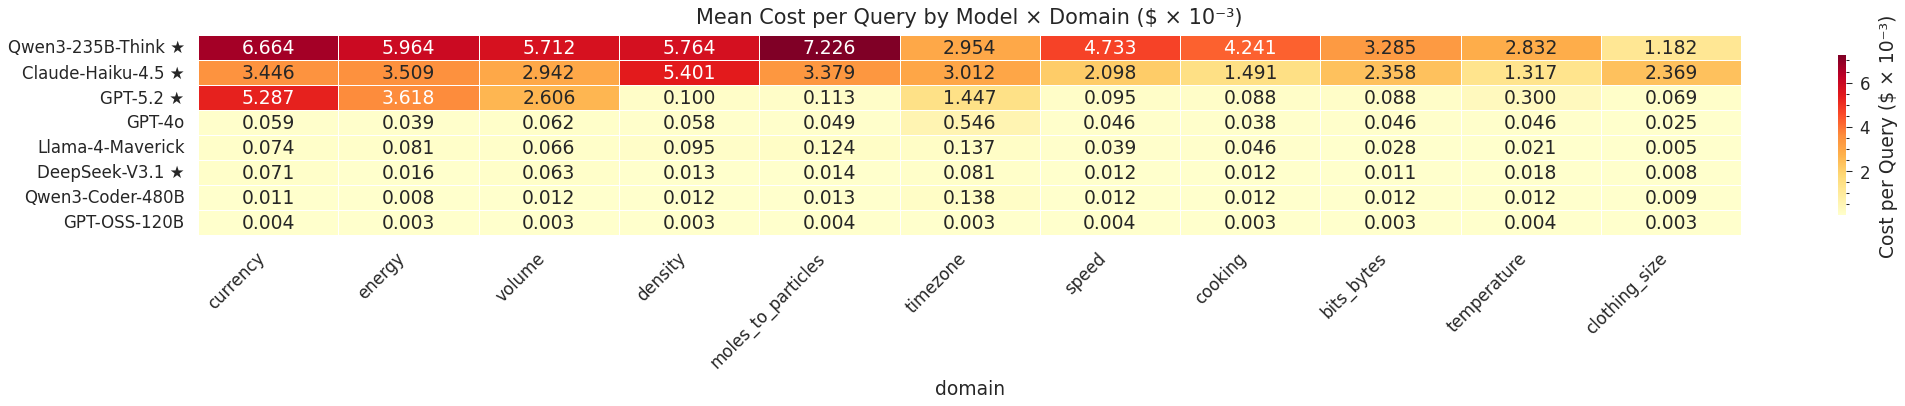

In [6]:
# ── 3. Cost by Domain ──

domain_cost = (
    df.groupby(['model', 'domain'])
    .agg(mean_tokens=('output_tokens', 'mean'),
         mean_cost=('cost_usd', 'mean'),
         total_cost=('cost_usd', 'sum'),
         accuracy=('is_correct', 'mean'))
    .reset_index()
)
domain_cost['accuracy_%'] = domain_cost['accuracy'] * 100

print("=== Mean Cost per Query ($×10⁻³) by Model × Domain ===")
pivot_dom = domain_cost.pivot(index='model', columns='domain', values='mean_cost').mul(1000)
pivot_dom.index = pivot_dom.index.map(lambda m: MODEL_DISPLAY.get(m, m))
pivot_dom = pivot_dom.loc[pivot_dom.mean(axis=1).sort_values(ascending=False).index,
                          pivot_dom.mean(axis=0).sort_values(ascending=False).index]
print(pivot_dom.round(4).to_string())

# Heatmap: mean cost by model × domain
fig, ax = plt.subplots(figsize=(PAGE_W * 2, PAGE_W * 0.4))
sns.heatmap(pivot_dom, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Cost per Query ($ × 10⁻³)', 'shrink': 0.8}, ax=ax)
ax.set_title('Mean Cost per Query by Model × Domain ($ × 10⁻³)')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

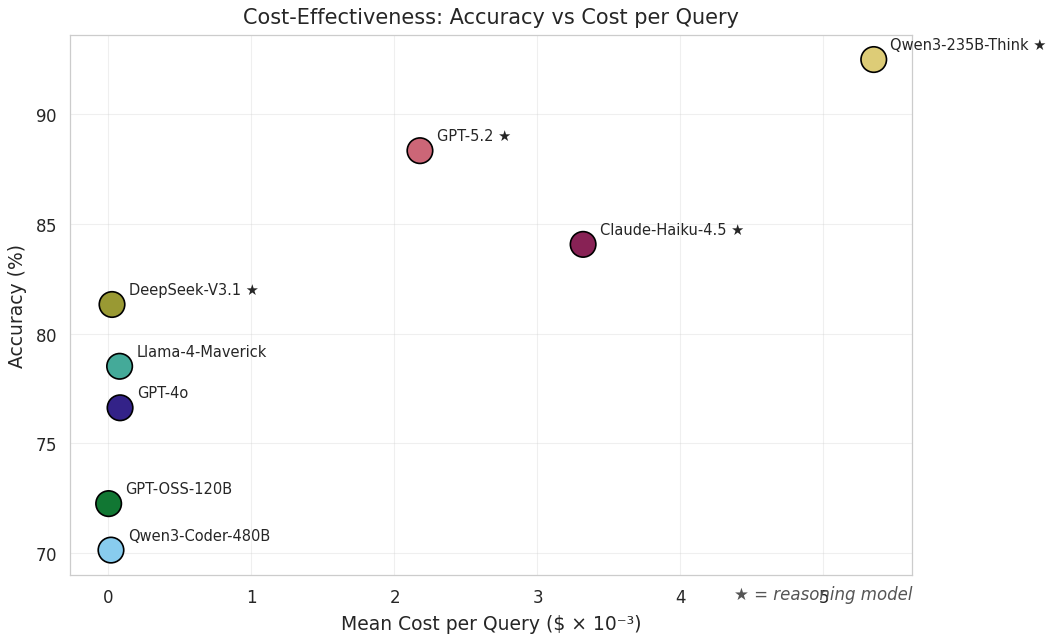

=== Cost-Effectiveness Summary ===
             model accuracy_% mean_cost total_cost correct_per_dollar
  Llama-4-Maverick      78.5% $0.000080     $37.56              9,835
            GPT-4o      76.6% $0.000083     $39.08              9,223
         GPT-5.2 ★      88.3% $0.002179   $1025.36                405
  Qwen3-Coder-480B      70.1% $0.000020      $9.18             35,944
   DeepSeek-V3.1 ★      81.3% $0.000027     $10.96             30,339
Claude-Haiku-4.5 ★      84.1% $0.003320    $802.27                253
      GPT-OSS-120B      72.2% $0.000003      $0.81            216,210
Qwen3-235B-Think ★      92.5% $0.005351   $2187.14                173


In [7]:
# ── 4. Cost-Effectiveness: Accuracy per Dollar ──

model_eff = (
    df.groupby('model')
    .agg(accuracy=('is_correct', 'mean'),
         mean_cost=('cost_usd', 'mean'),
         total_cost=('cost_usd', 'sum'),
         n=('cost_usd', 'size'))
    .reset_index()
)
model_eff['accuracy_%'] = model_eff['accuracy'] * 100
model_eff['correct_per_dollar'] = (model_eff['accuracy'] * model_eff['n']) / model_eff['total_cost']

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN))
colors = [MODEL_PALETTE.get(m, CB_PALETTE[0]) for m in model_eff['model']]
scatter = ax.scatter(model_eff['mean_cost'] * 1000, model_eff['accuracy_%'],
                     s=150, c=colors, edgecolors='black', linewidth=0.8, zorder=3)

for _, row in model_eff.iterrows():
    ax.annotate(MODEL_DISPLAY.get(row['model'], row['model']),
                (row['mean_cost'] * 1000, row['accuracy_%']),
                textcoords='offset points', xytext=(8, 5), fontsize=7)

ax.set_xlabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Cost-Effectiveness: Accuracy vs Cost per Query')
ax.grid(alpha=0.3)
ax.annotate('★ = reasoning model', xy=(1.0, -0.02), xycoords='axes fraction',
            fontsize=8, va='top', ha='right', style='italic', color='#555555')
plt.tight_layout()
plt.show()

print("=== Cost-Effectiveness Summary ===")
eff_display = model_eff[['model', 'accuracy_%', 'mean_cost', 'total_cost', 'correct_per_dollar']].copy()
eff_display['mean_cost'] = eff_display['mean_cost'].map('${:.6f}'.format)
eff_display['total_cost'] = eff_display['total_cost'].map('${:.2f}'.format)
eff_display['accuracy_%'] = eff_display['accuracy_%'].map('{:.1f}%'.format)
eff_display['correct_per_dollar'] = eff_display['correct_per_dollar'].map('{:,.0f}'.format)
eff_display['model'] = eff_display['model'].map(lambda m: MODEL_DISPLAY.get(m, m))
print(eff_display.sort_values('correct_per_dollar', ascending=False).to_string(index=False))

In [8]:
# ── 5. Reasoning Models Deep Dive: Reasoning Token Cost ──

df_reason = df[df['model'].isin(REASONING_MODELS)].copy()

reason_stats = (
    df_reason.groupby(['model', 'condition'])
    .agg(mean_reasoning_tok=('reasoning_tokens', 'mean'),
         mean_output_tok=('output_tokens', 'mean'),
         reasoning_share=('reasoning_tokens', lambda x: x.sum() / df_reason.loc[x.index, 'output_tokens'].sum()),
         mean_cost=('cost_usd', 'mean'),
         accuracy=('is_correct', 'mean'))
    .reset_index()
)
reason_stats['accuracy_%'] = reason_stats['accuracy'] * 100
reason_stats['reasoning_share_%'] = reason_stats['reasoning_share'] * 100

print("=== Reasoning Models: Token Breakdown by Condition ===")
for m in REASONING_MODELS:
    sub = reason_stats[reason_stats['model'] == m]
    if len(sub) == 0:
        continue
    print(f"\n{MODEL_DISPLAY.get(m, m)}:")
    for _, row in sub.iterrows():
        print(f"  {row['condition']:30s}  "
              f"reasoning: {row['mean_reasoning_tok']:6.0f} tok  "
              f"total: {row['mean_output_tok']:6.0f} tok  "
              f"reasoning share: {row['reasoning_share_%']:5.1f}%  "
              f"cost: ${row['mean_cost']*1000:.3f}×10⁻³  "
              f"acc: {row['accuracy_%']:.1f}%")

=== Reasoning Models: Token Breakdown by Condition ===

GPT-5.2 ★:
  in_domain_no_guide              reasoning:     44 tok  total:     51 tok  reasoning share:  86.4%  cost: $0.709×10⁻³  acc: 79.6%
  in_domain_with_guide            reasoning:    261 tok  total:    269 tok  reasoning share:  97.3%  cost: $3.764×10⁻³  acc: 96.2%
  math_only                       reasoning:    155 tok  total:    162 tok  reasoning share:  95.6%  cost: $2.271×10⁻³  acc: 96.1%

DeepSeek-V3.1 ★:
  in_domain_no_guide              reasoning:      0 tok  total:     10 tok  reasoning share:   0.0%  cost: $0.017×10⁻³  acc: 79.1%
  in_domain_with_guide            reasoning:      0 tok  total:     22 tok  reasoning share:   0.0%  cost: $0.038×10⁻³  acc: 82.6%
  math_only                       reasoning:      0 tok  total:     13 tok  reasoning share:   0.0%  cost: $0.022×10⁻³  acc: 91.2%

Qwen3-235B-Think ★:
  in_domain_no_guide              reasoning:      0 tok  total:   1653 tok  reasoning share:   0.0%  cost: $

In [9]:
# # ── 5b. Percentage Jump in Reasoning Trace Length: Math Only → No Guide ──
# #
# # reasoning_tokens is only reported by GPT-5.2 and Claude-Haiku-4.5.
# # DeepSeek-V3.1 and Qwen3-235B embed reasoning in the response text,
# # so we use response_len / 4 (≈ est_output_tokens) as the trace proxy.

# df_reason = df[df['model'].isin(REASONING_MODELS)].copy()

# MODELS_WITH_RT = {'gpt-5.2', 'claude-haiku-4-5'}
# df_reason['trace_tokens'] = np.where(
#     df_reason['model'].isin(MODELS_WITH_RT) & (df_reason['reasoning_tokens'] > 0),
#     df_reason['reasoning_tokens'],
#     df_reason['est_output_tokens'],
# )

# mo_reason = df_reason[df_reason['condition'] == 'math_only']
# ng_reason = df_reason[df_reason['condition'] == 'in_domain_no_guide']

# rows = []
# for m in REASONING_MODELS:
#     mo_vals = mo_reason.loc[mo_reason['model'] == m, 'trace_tokens'].values.astype(float)
#     ng_vals = ng_reason.loc[ng_reason['model'] == m, 'trace_tokens'].values.astype(float)
#     if len(mo_vals) == 0 or len(ng_vals) == 0:
#         continue
#     mo_mean, ng_mean = mo_vals.mean(), ng_vals.mean()
#     pct_change = (ng_mean / mo_mean - 1) * 100

#     boot_pcts = np.empty(N_BOOT)
#     for i in range(N_BOOT):
#         bm = mo_vals[rng.integers(0, len(mo_vals), size=len(mo_vals))].mean()
#         bn = ng_vals[rng.integers(0, len(ng_vals), size=len(ng_vals))].mean()
#         boot_pcts[i] = (bn / bm - 1) * 100
#     ci_lo, ci_hi = np.percentile(boot_pcts, [2.5, 97.5])

#     trace_src = 'reasoning_tokens' if m in MODELS_WITH_RT else 'response_len proxy'
#     rows.append(dict(model=m, display=MODEL_DISPLAY.get(m, m),
#                      trace_src=trace_src,
#                      math_only_mean=mo_mean, no_guide_mean=ng_mean,
#                      pct_change=pct_change, ci_lo=ci_lo, ci_hi=ci_hi,
#                      n_math=len(mo_vals), n_ng=len(ng_vals)))

# jump_df = pd.DataFrame(rows).sort_values('pct_change', ascending=False)

# # ── Pooled (all reasoning models) ──
# pool_mo = mo_reason['trace_tokens'].values.astype(float)
# pool_ng = ng_reason['trace_tokens'].values.astype(float)
# pool_pct = (pool_ng.mean() / pool_mo.mean() - 1) * 100
# boot_pool = np.empty(N_BOOT)
# for i in range(N_BOOT):
#     bm = pool_mo[rng.integers(0, len(pool_mo), size=len(pool_mo))].mean()
#     bn = pool_ng[rng.integers(0, len(pool_ng), size=len(pool_ng))].mean()
#     boot_pool[i] = (bn / bm - 1) * 100
# pool_ci_lo, pool_ci_hi = np.percentile(boot_pool, [2.5, 97.5])

# print("=" * 80)
# print("Reasoning Trace Length: Math Only → In-Domain No Guide  (% change)")
# print("=" * 80)
# for _, r in jump_df.iterrows():
#     print(f"  {r['display']:28s}  "
#           f"math_only: {r['math_only_mean']:8.0f} tok → no_guide: {r['no_guide_mean']:8.0f} tok  "
#           f"Δ = {r['pct_change']:+.1f}%  95% CI [{r['ci_lo']:+.1f}%, {r['ci_hi']:+.1f}%]"
#           f"  ({r['trace_src']})")
# print(f"\n  {'Pooled (all reasoning)':28s}  "
#       f"math_only: {pool_mo.mean():8.0f} tok → no_guide: {pool_ng.mean():8.0f} tok  "
#       f"Δ = {pool_pct:+.1f}%  95% CI [{pool_ci_lo:+.1f}%, {pool_ci_hi:+.1f}%]")

# # ── Bar chart ──
# fig, ax = plt.subplots(figsize=(COL_W * 2, COL_W * 1.1))
# x = np.arange(len(jump_df))
# colors = [COND_COLORS.get('in_domain_no_guide', '#44AA99')
#           if v > 0 else '#882255' for v in jump_df['pct_change']]
# yerr_lo = jump_df['pct_change'].values - jump_df['ci_lo'].values
# yerr_hi = jump_df['ci_hi'].values - jump_df['pct_change'].values
# bars = ax.bar(x, jump_df['pct_change'], color=colors, edgecolor='white', width=0.55,
#               yerr=[yerr_lo, yerr_hi], error_kw=ERR_KW)
# ax.bar_label(bars, fmt='%+.1f%%', fontsize=8, padding=3)

# ax.axhline(pool_pct, ls='--', lw=0.9, color='#332288', alpha=0.7,
#            label=f'Pooled mean: {pool_pct:+.1f}%')
# ax.axhline(0, lw=0.5, color='black')
# ax.set_xticks(x)
# ax.set_xticklabels(jump_df['display'], rotation=30, ha='right')
# ax.set_ylabel('Δ Reasoning Trace Length (%)')
# ax.set_title('Reasoning Trace Length Change:\nIn-Domain No Guide vs Math Only (95% CI)')
# ax.legend(fontsize=7, loc='best')
# ax.grid(axis='y', alpha=0.3)
# fig.tight_layout()
# save_fig(fig, 'reasoning_trace_pct_jump_math_vs_noguide')
# plt.show()

error_type distribution after merge:
error_type
correct            2989047
moderate_error       78083
large_error          66020
rounding             23445
magnitude_error      21975
changed_answer       19790
decimal_shift        18757
extra_factor         15331
refusal               4628
degenerate_loop        200
sign_error               4

Correct: 2,989,047 / 3,237,280

=== Average Cost by Error Type ===
                       n mean_tokens median_tokens  mean_cost median_cost total_cost
error_type                                                                          
sign_error             4         904           888  $0.004518   $0.004439      $0.02
changed_answer     19790        1038           712  $0.004208   $0.003496     $83.28
refusal             4628         823           828  $0.004057   $0.004137     $18.78
magnitude_error    21975         549           563  $0.002544   $0.002729     $55.89
extra_factor       15331         490             6  $0.001520   $0.000037    

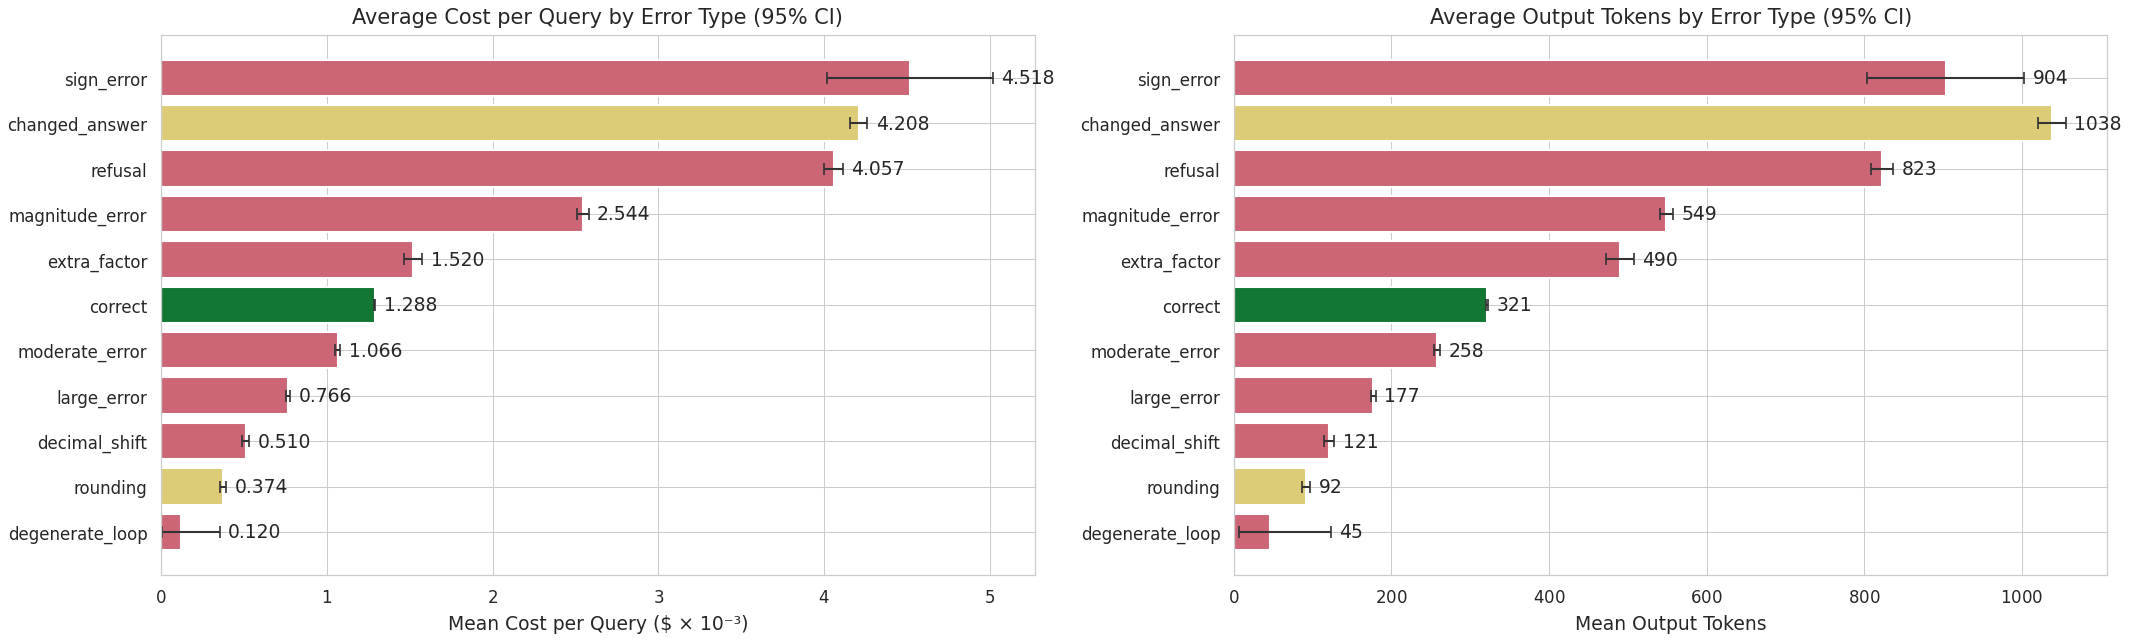

In [10]:
# ── 6. Cost by Error Type ──

errors_df = pd.read_csv(
    '/data/jane/convert/math_gender/conversion_test/3_error_taxonomy/error_mappings/all_errors.tsv',
    sep='\t', low_memory=False,
    usecols=['domain', 'number', 'answer', 'model', 'condition', 'distractor', 'error_type']
)

merge_keys = ['model', 'domain', 'condition', 'number', 'answer', 'distractor']
errors_df[merge_keys] = errors_df[merge_keys].astype(str)
df[merge_keys] = df[merge_keys].astype(str)

df = df.merge(errors_df[merge_keys + ['error_type']], on=merge_keys, how='left')
df['error_type'] = df['error_type'].fillna('correct')

print(f"error_type distribution after merge:")
print(df['error_type'].value_counts().to_string())
print(f"\nCorrect: {(df['error_type']=='correct').sum():,} / {len(df):,}")

# ── Summary table: cost by error type ──
etype_cost = (
    df.groupby('error_type')
    .agg(n=('cost_usd', 'size'),
         mean_tokens=('output_tokens', 'mean'),
         median_tokens=('output_tokens', 'median'),
         mean_cost=('cost_usd', 'mean'),
         median_cost=('cost_usd', 'median'),
         total_cost=('cost_usd', 'sum'))
    .sort_values('mean_cost', ascending=False)
)

print("\n=== Average Cost by Error Type ===")
display_et = etype_cost.copy()
display_et['mean_tokens'] = display_et['mean_tokens'].map('{:.0f}'.format)
display_et['median_tokens'] = display_et['median_tokens'].map('{:.0f}'.format)
display_et['mean_cost'] = display_et['mean_cost'].map('${:.6f}'.format)
display_et['median_cost'] = display_et['median_cost'].map('${:.6f}'.format)
display_et['total_cost'] = display_et['total_cost'].map('${:.2f}'.format)
print(display_et.to_string())

# ── Bar chart: mean cost per query by error type ──
fig, axes = plt.subplots(1, 2, figsize=(PAGE_W * 2, PAGE_W / GOLDEN))

order = etype_cost.index.tolist()
soft_types = {'rounding', 'changed_answer'}
colors = ['#117733' if e == 'correct' else '#DDCC77' if e in soft_types else '#CC6677'
          for e in order]

ax = axes[0]
cost_vals = etype_cost['mean_cost'].values * 1000
ci_cost = [bootstrap_ci_mean(df[df['error_type'] == e]['cost_usd']) for e in order]
xerr_lo_c = cost_vals - np.array([lo * 1000 for lo, hi in ci_cost])
xerr_hi_c = np.array([hi * 1000 for lo, hi in ci_cost]) - cost_vals
bars = ax.barh(order, cost_vals, color=colors, edgecolor='white',
               xerr=[xerr_lo_c, xerr_hi_c], error_kw=ERR_KW)
ax.set_xlabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_title('Average Cost per Query by Error Type (95% CI)')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.invert_yaxis()

ax = axes[1]
tok_vals = etype_cost['mean_tokens'].values
ci_tok = [bootstrap_ci_mean(df[df['error_type'] == e]['output_tokens']) for e in order]
xerr_lo_t = tok_vals - np.array([lo for lo, hi in ci_tok])
xerr_hi_t = np.array([hi for lo, hi in ci_tok]) - tok_vals
bars = ax.barh(order, tok_vals, color=colors, edgecolor='white',
               xerr=[xerr_lo_t, xerr_hi_t], error_kw=ERR_KW)
ax.set_xlabel('Mean Output Tokens')
ax.set_title('Average Output Tokens by Error Type (95% CI)')
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

=== Correct vs Wrong: Cost Comparison ===
                n  mean_tokens  mean_cost   total_cost
is_wrong                                              
Correct   2989047   321.439767   0.001288  3848.757351
Wrong      248233   323.080015   0.001343   333.471220

Wrong answers cost 1.04× as much as correct answers on average


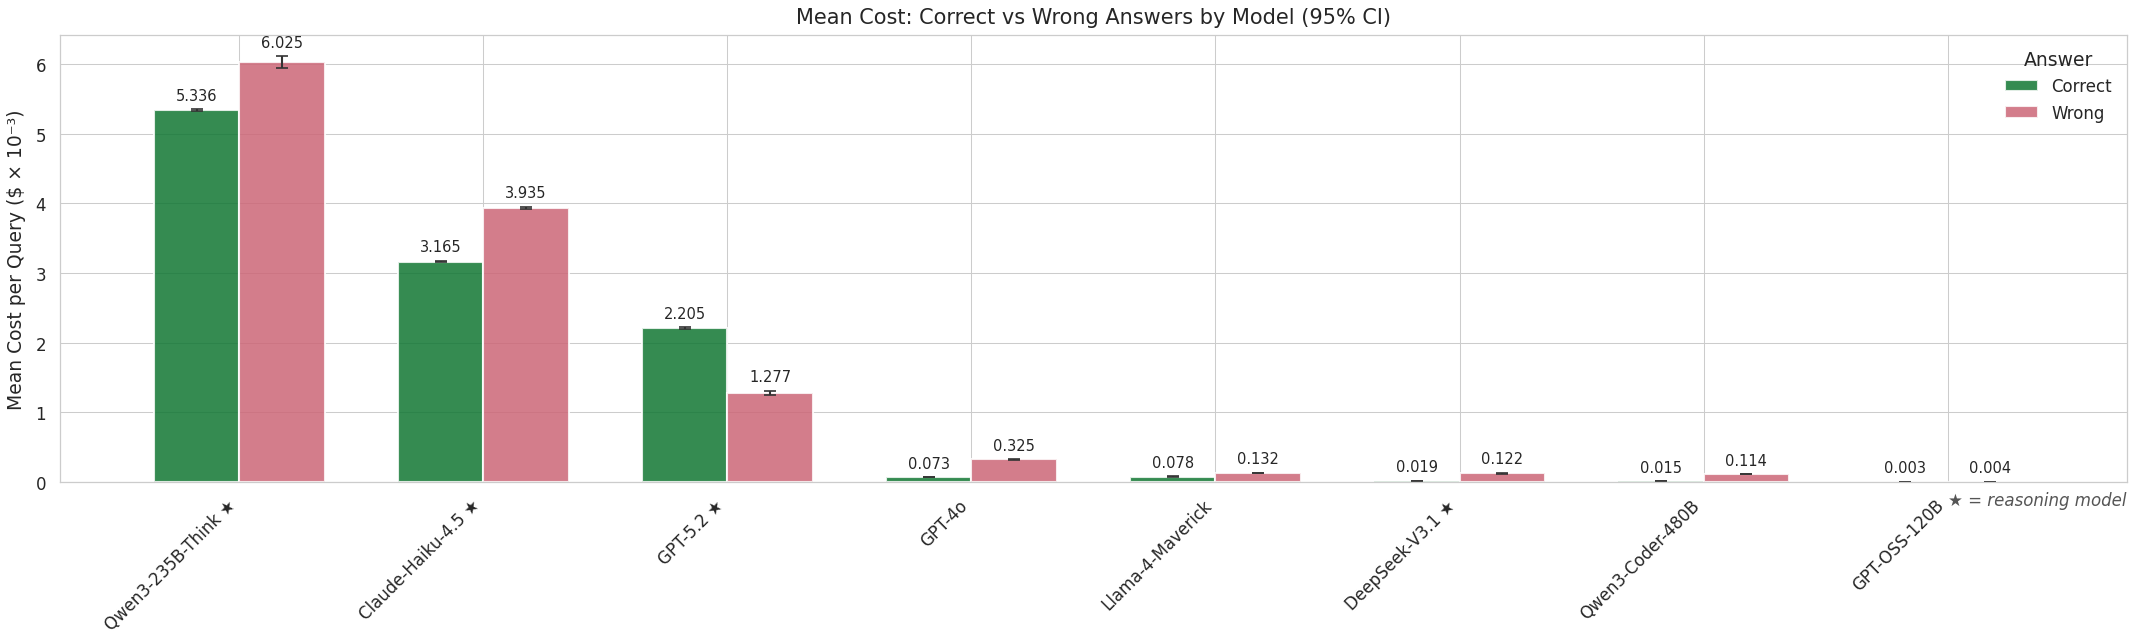

In [11]:
# ── 7. Correct vs Wrong: Cost Comparison ──

df['is_wrong'] = df['error_type'] != 'correct'
correct_vs_wrong = (
    df.groupby('is_wrong')
    .agg(n=('cost_usd', 'size'),
         mean_tokens=('output_tokens', 'mean'),
         mean_cost=('cost_usd', 'mean'),
         total_cost=('cost_usd', 'sum'))
    .rename(index={False: 'Correct', True: 'Wrong'})
)
print("=== Correct vs Wrong: Cost Comparison ===")
print(correct_vs_wrong.to_string())
print(f"\nWrong answers cost {correct_vs_wrong.loc['Wrong','mean_cost']/correct_vs_wrong.loc['Correct','mean_cost']:.2f}× "
      f"as much as correct answers on average")

# Per-model breakdown: correct vs wrong cost
model_cw = (
    df.groupby(['model', 'is_wrong'])
    .agg(mean_tokens=('output_tokens', 'mean'), mean_cost=('cost_usd', 'mean'))
    .reset_index()
)
model_cw['label'] = model_cw['is_wrong'].map({False: 'Correct', True: 'Wrong'})

fig, ax = plt.subplots(figsize=(PAGE_W * 2, PAGE_W / GOLDEN))
models_sorted = df.groupby('model')['cost_usd'].mean().sort_values(ascending=False).index
n_m = len(models_sorted)
bw = 0.35
x = np.arange(n_m)

for j, (wrong_val, lbl, color) in enumerate([(False, 'Correct', '#117733'), (True, 'Wrong', '#CC6677')]):
    vals, yerr_lo, yerr_hi = [], [], []
    for m in models_sorted:
        row = model_cw[(model_cw['model'] == m) & (model_cw['is_wrong'] == wrong_val)]
        v = row['mean_cost'].values[0] * 1000 if len(row) else 0
        vals.append(v)
        sub = df[(df['model'] == m) & (df['is_wrong'] == wrong_val)]['cost_usd']
        lo, hi = bootstrap_ci_mean(sub)
        yerr_lo.append(v - lo * 1000)
        yerr_hi.append(hi * 1000 - v)
    offset = x + (j - 0.5) * bw
    bars = ax.bar(offset, vals, bw, label=lbl, color=color, edgecolor='white', alpha=0.85,
                  yerr=[yerr_lo, yerr_hi], error_kw=ERR_KW)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=3)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in models_sorted], rotation=45, ha='right')
ax.set_ylabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_title('Mean Cost: Correct vs Wrong Answers by Model (95% CI)')
ax.legend(title='Answer', framealpha=0.9)
ax.annotate('★ = reasoning model', xy=(1.0, -0.02), xycoords='axes fraction',
            fontsize=8, va='top', ha='right', style='italic', color='#555555')
plt.tight_layout()
plt.show()

=== Mean Cost ($ × 10⁻³) by Error Type — Reasoning Models ===
error_type          correct  rounding  changed_answer  decimal_shift  extra_factor  sign_error  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
model                                                                                                                                                                 
Claude-Haiku-4.5 ★   3.1645    4.5066          3.5055         3.0850        4.8064      4.5178          4.4764           4.1861       3.2720   4.2492           0.0000
DeepSeek-V3.1 ★      0.0194    0.0337          9.9016         0.2382        0.1052      0.0000          0.0955           2.4684       0.0784   0.9953           0.0000
GPT-5.2 ★            2.2047    0.3697          0.0000         0.0981        0.0994      0.0000          1.5411           0.1047       2.1308   0.0000           0.0000
Qwen3-235B-Think ★   5.3355    4.1260          9.5994         9.5934        7.5471      0.0000         

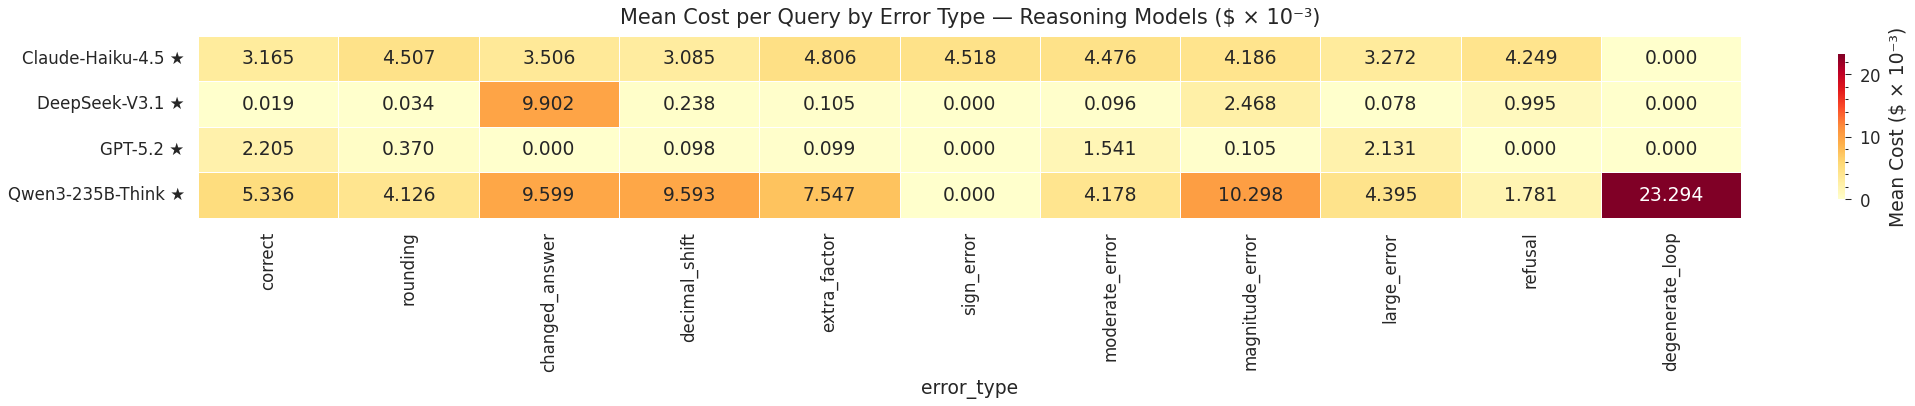

In [12]:
# ── 8. Cost by Error Type × Model (reasoning models) ──

df_rm = df[df['model'].isin(REASONING_MODELS)].copy()

error_order = ['correct', 'rounding', 'changed_answer', 'decimal_shift', 'extra_factor',
               'sign_error', 'moderate_error', 'magnitude_error', 'large_error',
               'refusal', 'degenerate_loop']
present_types = [e for e in error_order if e in df_rm['error_type'].unique()]

pivot = df_rm.groupby(['model', 'error_type'])['cost_usd'].mean().mul(1000).unstack(fill_value=0)
pivot = pivot.reindex(columns=[e for e in present_types if e in pivot.columns], fill_value=0)
pivot.index = pivot.index.map(lambda m: MODEL_DISPLAY.get(m, m))

print("=== Mean Cost ($ × 10⁻³) by Error Type — Reasoning Models ===")
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(PAGE_W * 2, PAGE_W * 0.4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Mean Cost ($ × 10⁻³)', 'shrink': 0.8}, ax=ax)
ax.set_title('Mean Cost per Query by Error Type — Reasoning Models ($ × 10⁻³)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Matched prompts:  math_only ↔ no_guide: 196,148
                  math_only ↔ with_guide: 192,553

=== No-Guide vs Math-Only: Mean Cost Gap by Model ===
                    Math ($×10⁻³)  NoGuide ($×10⁻³)  Diff ($×10⁻³)  Token Diff  Cost Ratio
model                                                                                     
Claude-Haiku-4.5 ★         1.7874            3.8241         2.0367    407.3306      3.3494
Qwen3-235B-Think ★         3.0751            4.6839         1.6087    536.2494      2.0439
GPT-5.2 ★                  2.5051            3.6793         1.1742     83.8713      2.7809
Llama-4-Maverick           0.0205            0.0826         0.0621     73.0504     14.6636
DeepSeek-V3.1 ★            0.0180            0.0315         0.0135      7.9472      2.5632
Qwen3-Coder-480B           0.0152            0.0220         0.0068      3.3888      1.5445
GPT-OSS-120B               0.0036            0.0044         0.0008      1.2510      1.2341
GPT-4o                     0

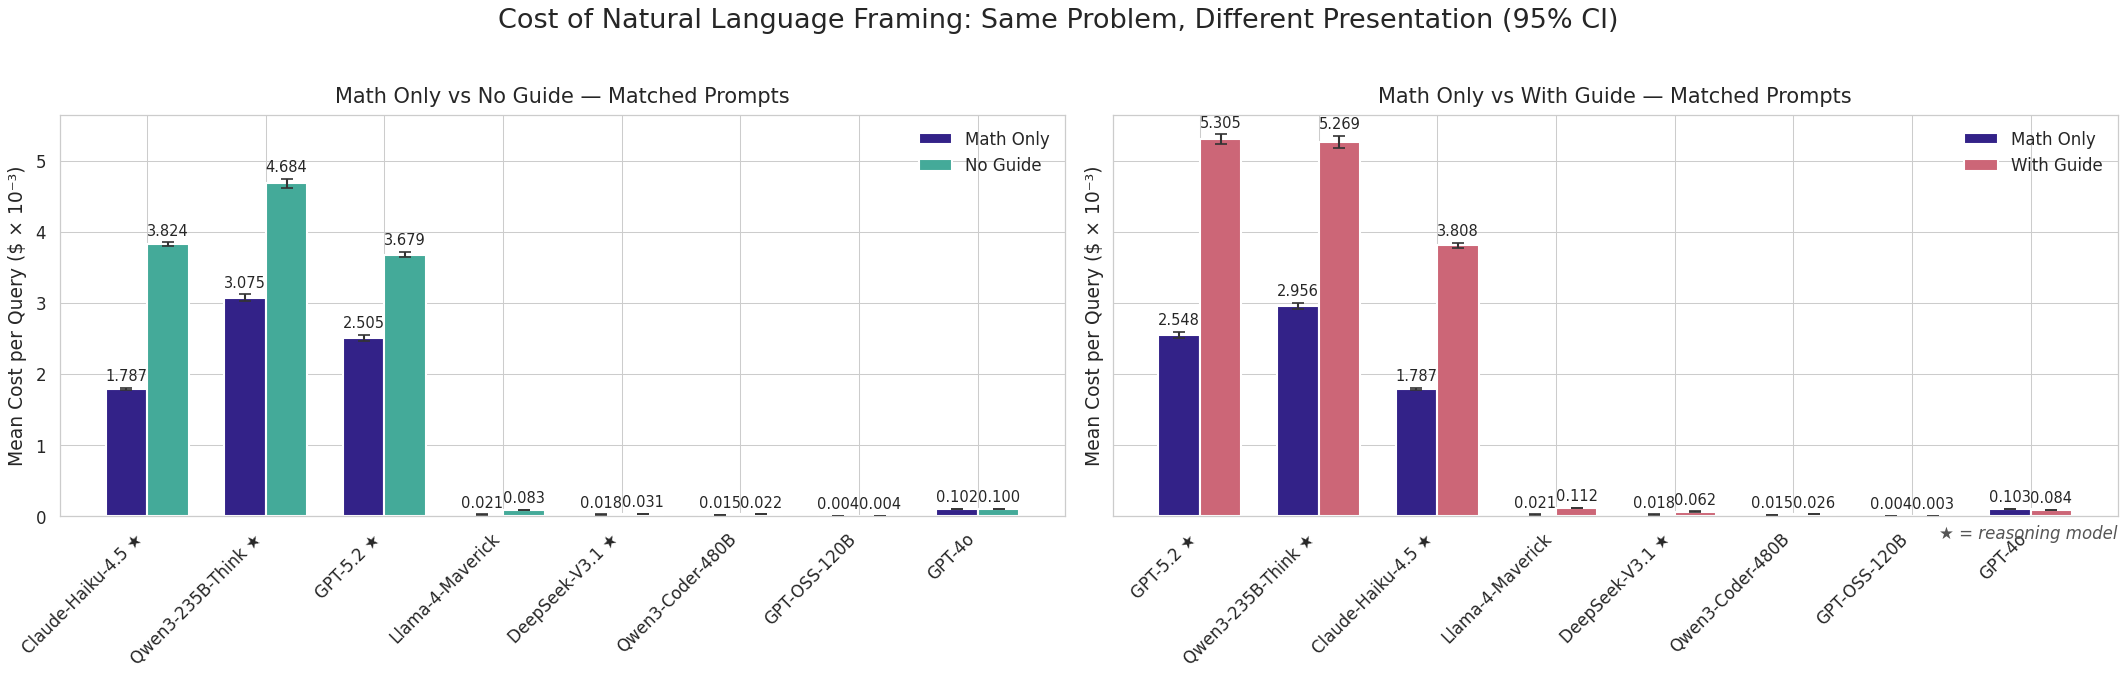

In [13]:
# ── 9. Matched Prompt Cost: Math Only vs Natural Language ──

match_keys = ['domain', 'number', 'answer', 'model']

# Average cost per problem within each condition (collapses distractor variants)
matched = (
    df.groupby(match_keys + ['condition'])
    .agg(mean_tokens=('output_tokens', 'mean'), mean_cost=('cost_usd', 'mean'))
    .reset_index()
)

mo = matched[matched['condition'] == 'math_only'].set_index(match_keys)
ng = matched[matched['condition'] == 'in_domain_no_guide'].set_index(match_keys)
wg = matched[matched['condition'] == 'in_domain_with_guide'].set_index(match_keys)

common_mo_ng = mo.index.intersection(ng.index)
common_mo_wg = mo.index.intersection(wg.index)
print(f"Matched prompts:  math_only ↔ no_guide: {len(common_mo_ng):,}")
print(f"                  math_only ↔ with_guide: {len(common_mo_wg):,}")

# Build paired DataFrames
pairs_ng = pd.DataFrame({
    'model': [k[3] for k in common_mo_ng],
    'domain': [k[0] for k in common_mo_ng],
    'math_cost': mo.loc[common_mo_ng, 'mean_cost'].values,
    'math_tokens': mo.loc[common_mo_ng, 'mean_tokens'].values,
    'ng_cost': ng.loc[common_mo_ng, 'mean_cost'].values,
    'ng_tokens': ng.loc[common_mo_ng, 'mean_tokens'].values,
})
pairs_ng['cost_diff'] = pairs_ng['ng_cost'] - pairs_ng['math_cost']
pairs_ng['token_diff'] = pairs_ng['ng_tokens'] - pairs_ng['math_tokens']
pairs_ng['cost_ratio'] = pairs_ng['ng_cost'] / pairs_ng['math_cost'].clip(lower=1e-12)

pairs_wg = pd.DataFrame({
    'model': [k[3] for k in common_mo_wg],
    'domain': [k[0] for k in common_mo_wg],
    'math_cost': mo.loc[common_mo_wg, 'mean_cost'].values,
    'math_tokens': mo.loc[common_mo_wg, 'mean_tokens'].values,
    'wg_cost': wg.loc[common_mo_wg, 'mean_cost'].values,
    'wg_tokens': wg.loc[common_mo_wg, 'mean_tokens'].values,
})
pairs_wg['cost_diff'] = pairs_wg['wg_cost'] - pairs_wg['math_cost']
pairs_wg['token_diff'] = pairs_wg['wg_tokens'] - pairs_wg['math_tokens']
pairs_wg['cost_ratio'] = pairs_wg['wg_cost'] / pairs_wg['math_cost'].clip(lower=1e-12)

# ── Summary by model ──
print("\n=== No-Guide vs Math-Only: Mean Cost Gap by Model ===")
summary_ng = pairs_ng.groupby('model').agg(
    math_cost=('math_cost', 'mean'), ng_cost=('ng_cost', 'mean'),
    cost_diff=('cost_diff', 'mean'), token_diff=('token_diff', 'mean'),
    cost_ratio=('cost_ratio', 'mean'),
).sort_values('cost_diff', ascending=False)
summary_ng['math_cost'] = summary_ng['math_cost'].mul(1000)
summary_ng['ng_cost'] = summary_ng['ng_cost'].mul(1000)
summary_ng['cost_diff'] = summary_ng['cost_diff'].mul(1000)
summary_ng.columns = ['Math ($×10⁻³)', 'NoGuide ($×10⁻³)', 'Diff ($×10⁻³)', 'Token Diff', 'Cost Ratio']
summary_ng.index = summary_ng.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(summary_ng.round(4).to_string())

print("\n=== With-Guide vs Math-Only: Mean Cost Gap by Model ===")
summary_wg = pairs_wg.groupby('model').agg(
    math_cost=('math_cost', 'mean'), wg_cost=('wg_cost', 'mean'),
    cost_diff=('cost_diff', 'mean'), token_diff=('token_diff', 'mean'),
    cost_ratio=('cost_ratio', 'mean'),
).sort_values('cost_diff', ascending=False)
summary_wg['math_cost'] = summary_wg['math_cost'].mul(1000)
summary_wg['wg_cost'] = summary_wg['wg_cost'].mul(1000)
summary_wg['cost_diff'] = summary_wg['cost_diff'].mul(1000)
summary_wg.columns = ['Math ($×10⁻³)', 'WithGuide ($×10⁻³)', 'Diff ($×10⁻³)', 'Token Diff', 'Cost Ratio']
summary_wg.index = summary_wg.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(summary_wg.round(4).to_string())

# ── Visualization: paired bars ──
fig, axes = plt.subplots(1, 2, figsize=(PAGE_W * 2, PAGE_W / GOLDEN), sharey=True)

cond_pairs = [
    (pairs_ng, 'No Guide', 'ng_cost', 'in_domain_no_guide'),
    (pairs_wg, 'With Guide', 'wg_cost', 'in_domain_with_guide'),
]
for ax, (pairs, label, cost_col, cond_key) in zip(axes, cond_pairs):
    model_order = pairs.groupby('model')['cost_diff'].mean().sort_values(ascending=False).index
    n = len(model_order)
    x = np.arange(n)
    bw = 0.35

    math_vals, math_ylo, math_yhi = [], [], []
    nl_vals, nl_ylo, nl_yhi = [], [], []
    for m in model_order:
        sub = pairs[pairs['model'] == m]
        mv = sub['math_cost'].mean() * 1000
        math_vals.append(mv)
        lo, hi = bootstrap_ci_mean(sub['math_cost'])
        math_ylo.append(mv - lo * 1000)
        math_yhi.append(hi * 1000 - mv)
        nv = sub[cost_col].mean() * 1000
        nl_vals.append(nv)
        lo, hi = bootstrap_ci_mean(sub[cost_col])
        nl_ylo.append(nv - lo * 1000)
        nl_yhi.append(hi * 1000 - nv)

    bars1 = ax.bar(x - bw/2, math_vals, bw, label='Math Only',
                   color=COND_COLORS['math_only'], edgecolor='white',
                   yerr=[math_ylo, math_yhi], error_kw=ERR_KW)
    bars2 = ax.bar(x + bw/2, nl_vals, bw, label=label,
                   color=COND_COLORS[cond_key], edgecolor='white',
                   yerr=[nl_ylo, nl_yhi], error_kw=ERR_KW)

    ax.bar_label(bars1, fmt='%.3f', fontsize=7, padding=2)
    ax.bar_label(bars2, fmt='%.3f', fontsize=7, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in model_order], rotation=45, ha='right')
    ax.set_ylabel('Mean Cost per Query ($ × 10⁻³)')
    ax.set_title(f'Math Only vs {label} — Matched Prompts')
    ax.legend(framealpha=0.9)

axes[-1].annotate('★ = reasoning model', xy=(1.0, -0.02), xycoords='axes fraction',
                  fontsize=8, va='top', ha='right', style='italic', color='#555555')
plt.suptitle('Cost of Natural Language Framing: Same Problem, Different Presentation (95% CI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

=== No-Guide vs Math-Only: Mean Token Diff by Model × Domain ===
domain              currency  density  moles_to_particles  cooking  timezone  volume  energy  bits_bytes  temperature  speed
model                                                                                                                       
Qwen3-235B-Think ★       976      819                1039      711       400     606     378         458          327     59
Claude-Haiku-4.5 ★       506      774                 356       52       245      49     258         158            2     51
Llama-4-Maverick         110       40                 195       16       -64      26       0          -8           10     32
GPT-5.2 ★                126        0                  -1        0        33      -1       0           0          -45     -1
Qwen3-Coder-480B           0        0                  -1        0        47       0       0           0            0      0
DeepSeek-V3.1 ★            5        0                   1   

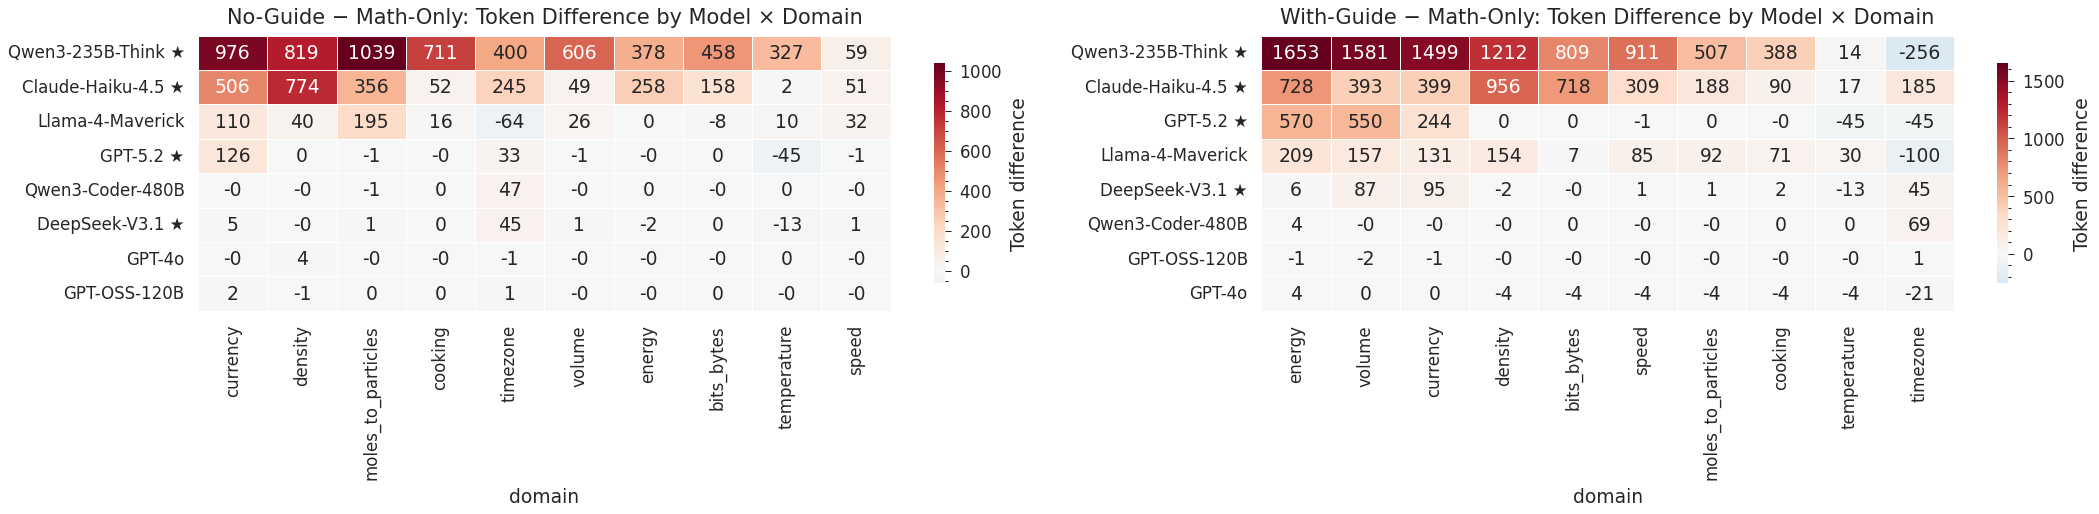

In [14]:
# ── 10. Cost Gap by Domain ──

print("=== No-Guide vs Math-Only: Mean Token Diff by Model × Domain ===")
pivot_ng_dom = pairs_ng.groupby(['model', 'domain'])['token_diff'].mean().unstack(fill_value=0)
pivot_ng_dom.index = pivot_ng_dom.index.map(lambda m: MODEL_DISPLAY.get(m, m))
pivot_ng_dom = pivot_ng_dom.loc[pivot_ng_dom.mean(axis=1).sort_values(ascending=False).index,
                                pivot_ng_dom.mean(axis=0).sort_values(ascending=False).index]
print(pivot_ng_dom.round(0).astype(int).to_string())

fig, axes = plt.subplots(1, 2, figsize=(PAGE_W * 2, PAGE_W * 0.5))

ax = axes[0]
sns.heatmap(pivot_ng_dom.round(0), annot=True, fmt='.0f', cmap='RdBu_r', center=0,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Token difference', 'shrink': 0.8}, ax=ax)
ax.set_title('No-Guide − Math-Only: Token Difference by Model × Domain')
ax.set_ylabel('')

print("\n=== With-Guide vs Math-Only: Mean Token Diff by Model × Domain ===")
pivot_wg_dom = pairs_wg.groupby(['model', 'domain'])['token_diff'].mean().unstack(fill_value=0)
pivot_wg_dom.index = pivot_wg_dom.index.map(lambda m: MODEL_DISPLAY.get(m, m))
pivot_wg_dom = pivot_wg_dom.loc[pivot_wg_dom.mean(axis=1).sort_values(ascending=False).index,
                                pivot_wg_dom.mean(axis=0).sort_values(ascending=False).index]
print(pivot_wg_dom.round(0).astype(int).to_string())

ax = axes[1]
sns.heatmap(pivot_wg_dom.round(0), annot=True, fmt='.0f', cmap='RdBu_r', center=0,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Token difference', 'shrink': 0.8}, ax=ax)
ax.set_title('With-Guide − Math-Only: Token Difference by Model × Domain')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

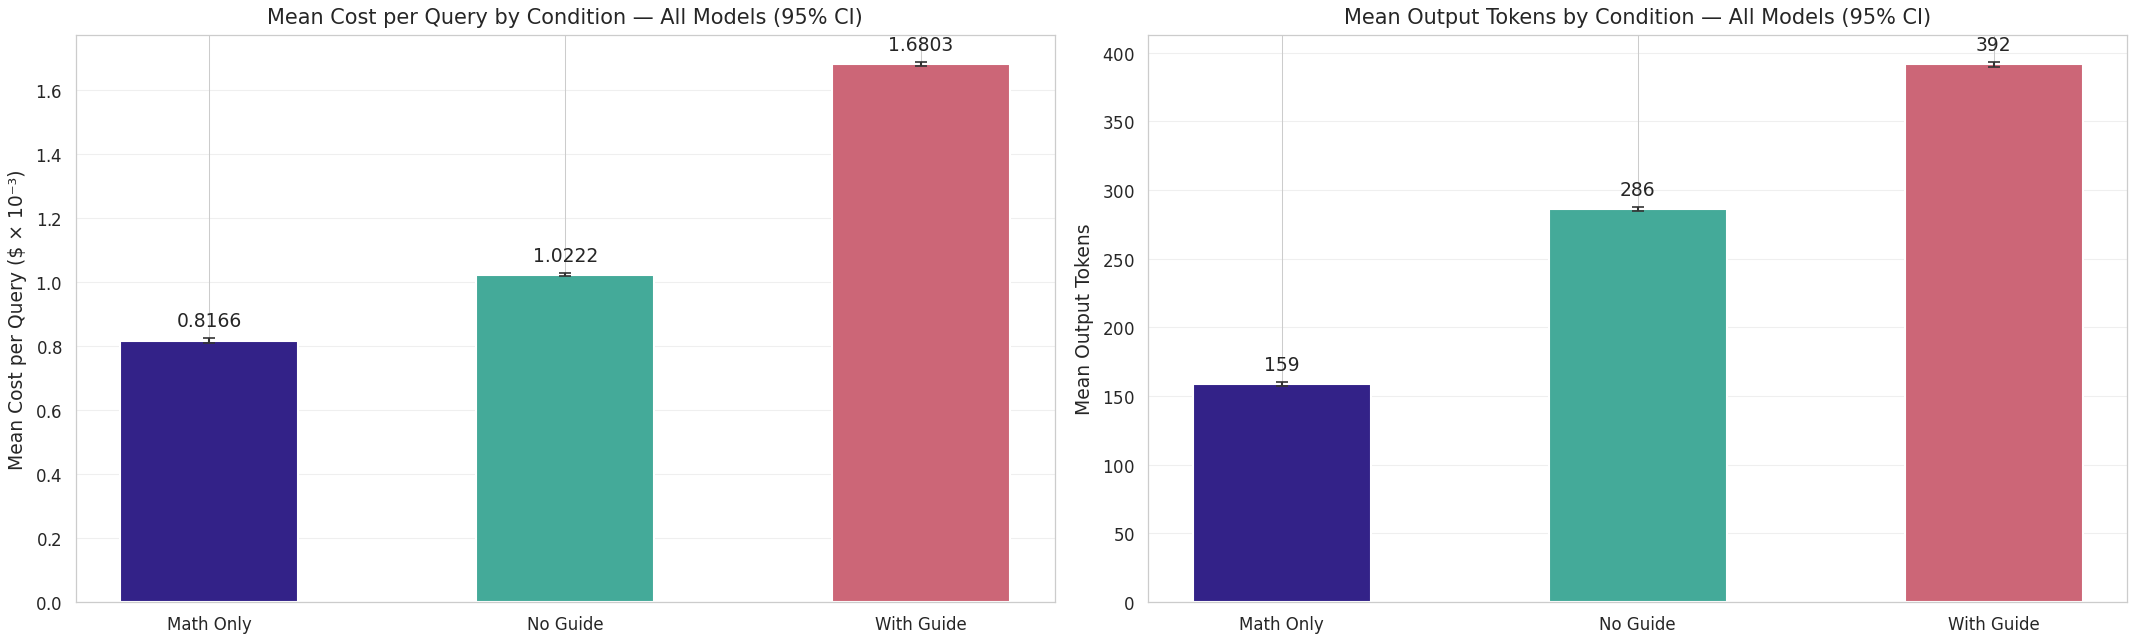

=== Cost by Condition (all models pooled) ===
  Math Only        cost: $0.8166×10⁻³  tokens: 159  n=269,161.0
  No Guide         cost: $1.0222×10⁻³  tokens: 286  n=1,557,280.0  (+25.2% vs Math Only)
  With Guide       cost: $1.6803×10⁻³  tokens: 392  n=1,410,839.0  (+105.8% vs Math Only)


In [15]:
# ── 11. Reasoning Cost by Condition (all models pooled) ──

cond_order = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']
cond_labels = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}

agg_cond = (
    df.groupby('condition')
    .agg(mean_cost=('cost_usd', 'mean'), median_cost=('cost_usd', 'median'),
         mean_tokens=('output_tokens', 'mean'), median_tokens=('output_tokens', 'median'),
         n=('cost_usd', 'size'))
    .reindex(cond_order)
)

fig, axes = plt.subplots(1, 2, figsize=(PAGE_W * 2, PAGE_W / GOLDEN))
palette = [COND_COLORS[c] for c in cond_order]
x = np.arange(len(cond_order))
labels = [cond_labels[c] for c in cond_order]

ax = axes[0]
cost_vals = agg_cond['mean_cost'].values * 1000
ci_c = [bootstrap_ci_mean(df[df['condition'] == c]['cost_usd']) for c in cond_order]
yerr_lo_c = cost_vals - np.array([lo * 1000 for lo, hi in ci_c])
yerr_hi_c = np.array([hi * 1000 for lo, hi in ci_c]) - cost_vals
bars = ax.bar(x, cost_vals, color=palette, edgecolor='white', width=0.5,
              yerr=[yerr_lo_c, yerr_hi_c], error_kw=ERR_KW)
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean Cost per Query ($ × 10⁻³)')
ax.set_title('Mean Cost per Query by Condition — All Models (95% CI)')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
tok_vals = agg_cond['mean_tokens'].values
ci_t = [bootstrap_ci_mean(df[df['condition'] == c]['output_tokens']) for c in cond_order]
yerr_lo_t = tok_vals - np.array([lo for lo, hi in ci_t])
yerr_hi_t = np.array([hi for lo, hi in ci_t]) - tok_vals
bars = ax.bar(x, tok_vals, color=palette, edgecolor='white', width=0.5,
              yerr=[yerr_lo_t, yerr_hi_t], error_kw=ERR_KW)
ax.bar_label(bars, fmt='%.0f', fontsize=9, padding=4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean Output Tokens')
ax.set_title('Mean Output Tokens by Condition — All Models (95% CI)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary ──
math_cost = agg_cond.loc['math_only', 'mean_cost']
print("=== Cost by Condition (all models pooled) ===")
for c in cond_order:
    row = agg_cond.loc[c]
    uplift = (row['mean_cost'] / math_cost - 1) * 100 if c != 'math_only' else 0
    print(f"  {cond_labels[c]:15s}  cost: ${row['mean_cost']*1000:.4f}×10⁻³  "
          f"tokens: {row['mean_tokens']:.0f}  n={row['n']:,}"
          f"{'  (+' + f'{uplift:.1f}% vs Math Only)' if uplift else ''}")

=== Time Cost per Model ===
                    Mean Latency (s)  Median Latency (s)  Secs/Token  Tokens/Sec  Mean Tokens
display                                                                                      
GPT-4o                          4.09                3.30        0.49        3.29        16.44
Claude-Haiku-4.5 ★              5.17                3.40        0.01      143.75       666.66
Qwen3-Coder-480B                8.12                6.76        1.08        1.52        14.25
Llama-4-Maverick               25.46               19.14        0.77        4.96       119.36
GPT-OSS-120B                   29.63               23.26        6.40        0.35         5.57
DeepSeek-V3.1 ★                31.90               23.16        5.22        0.90        15.75
Qwen3-235B-Think ★             66.13               38.53        3.26       40.59      1891.02
GPT-5.2 ★                      83.77               52.24        0.28        6.34       404.37
  → saved time_cost_latency_by_m

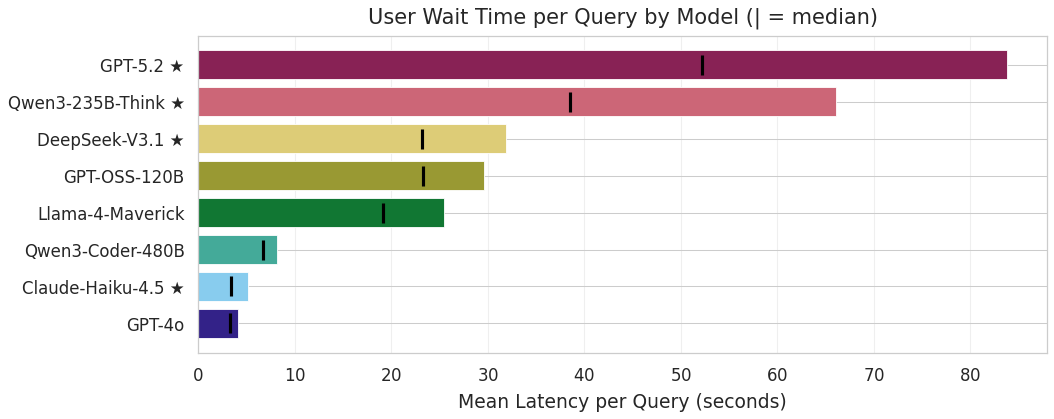

In [16]:
# ── 12. Time Cost: Latency as a User-Facing Cost ──
# Dollar cost captures API expense; wall-clock latency captures the cost
# exacted on the *user* who is waiting for a response.

df_time = df[df['call_seconds'].notna() & (df['output_tokens'] > 0)].copy()
df_time['secs_per_token'] = df_time['call_seconds'] / df_time['output_tokens']
df_time['tokens_per_sec'] = df_time['output_tokens'] / df_time['call_seconds']

time_stats = (
    df_time.groupby('model')
    .agg(
        mean_latency=('call_seconds', 'mean'),
        median_latency=('call_seconds', 'median'),
        mean_secs_per_tok=('secs_per_token', 'mean'),
        mean_tok_per_sec=('tokens_per_sec', 'mean'),
        mean_output_tokens=('output_tokens', 'mean'),
    )
    .reset_index()
)
time_stats['display'] = time_stats['model'].map(MODEL_DISPLAY)

print("=== Time Cost per Model ===")
fmt = time_stats.set_index('display')[
    ['mean_latency', 'median_latency', 'mean_secs_per_tok', 'mean_tok_per_sec', 'mean_output_tokens']
].round(2)
fmt.columns = ['Mean Latency (s)', 'Median Latency (s)', 'Secs/Token', 'Tokens/Sec', 'Mean Tokens']
print(fmt.sort_values('Mean Latency (s)').to_string())

# ── Fig A: Mean latency per query by model ──
models_by_latency = time_stats.sort_values('mean_latency', ascending=True)

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
colors = [CB_PALETTE[i % len(CB_PALETTE)] for i in range(len(models_by_latency))]
bars = ax.barh(
    [MODEL_DISPLAY.get(m, m) for m in models_by_latency['model']],
    models_by_latency['mean_latency'],
    color=colors, edgecolor='white', linewidth=0.4,
)
for bar, med in zip(bars, models_by_latency['median_latency']):
    ax.plot(med, bar.get_y() + bar.get_height() / 2, '|', color='black',
            markersize=10, markeredgewidth=1.5)
ax.set_xlabel('Mean Latency per Query (seconds)')
ax.set_title('User Wait Time per Query by Model (| = median)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'time_cost_latency_by_model')
plt.show()

  → saved time_cost_latency_by_condition.pdf / .png


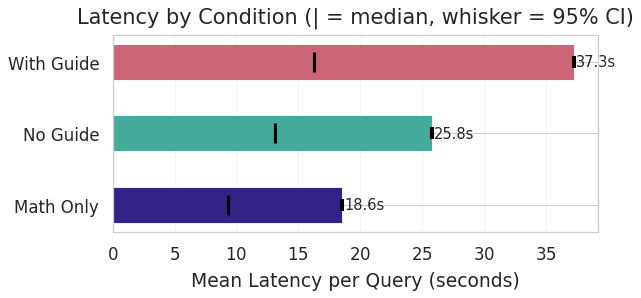

In [17]:
# ── Mean latency by condition (aggregated across all models) ─────
lat_cond = (
    df_time.groupby('condition')['call_seconds']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(COND_ORDER)
)
lat_cond['se'] = lat_cond['std'] / np.sqrt(lat_cond['count'])

fig, ax = plt.subplots(figsize=(PAGE_W * 0.6, COL_W / GOLDEN))
y = np.arange(len(COND_ORDER))
labels = [COND_LABELS[c] for c in COND_ORDER]
colors = [COND_COLORS[c] for c in COND_ORDER]

bars = ax.barh(y, lat_cond['mean'], xerr=lat_cond['se'] * 1.96,
               color=colors, edgecolor='white', linewidth=0.4,
               height=0.5, capsize=3)
for bar, mean, med in zip(bars, lat_cond['mean'], lat_cond['median']):
    ax.plot(med, bar.get_y() + bar.get_height() / 2, '|', color='black',
            markersize=10, markeredgewidth=1.5)
    ax.text(bar.get_width() + lat_cond['se'].max() * 2.5,
            bar.get_y() + bar.get_height() / 2,
            f'{mean:.1f}s', va='center', fontsize=7)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Mean Latency per Query (seconds)')
ax.set_title('Latency by Condition (| = median, whisker = 95% CI)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
save_fig(fig, 'time_cost_latency_by_condition')
plt.show()

In [18]:
# # ── Wait Time vs Loss: every prompt, colored by model ────────────
# # Each dot is one (model, prompt) observation.

# fig, ax = plt.subplots(figsize=(PAGE_W * 0.8, PAGE_W * 0.8 / GOLDEN))

# for model in MODEL_DISPLAY:
#     sub = df_time[df_time['model'] == model]
#     if sub.empty:
#         continue
#     ax.scatter(
#         sub['call_seconds'],
#         sub['loss'].clip(upper=200),
#         s=3, alpha=0.15, linewidths=0,
#         color=MODEL_PALETTE.get(model, '#999'),
#         label=MODEL_DISPLAY.get(model, model),
#         rasterized=True,
#     )

# ax.set_xlabel('Wait Time per Query (seconds)')
# ax.set_ylabel('Loss (%, clipped at 200)')
# ax.set_title('Per-Prompt Wait Time vs Loss')
# ax.legend(markerscale=4, fontsize=6.5, loc='upper right',
#           frameon=True, edgecolor='#cccccc', fancybox=False)
# ax.grid(alpha=0.2)
# plt.tight_layout()
# save_fig(fig, 'time_vs_loss_per_prompt')
# plt.show()

In [19]:
len(df_time)

2369737

In [20]:
df_time.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty', 'response_len',
       'est_output_tokens', 'output_tokens', 'cost_per_mtok', 'cost_usd',
       'error_type', 'is_wrong', 'secs_per_token', 'tokens_per_sec'],
      dtype='object')

In [21]:
df_time.head()

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,frequency_difficulty,response_len,est_output_tokens,output_tokens,cost_per_mtok,cost_usd,error_type,is_wrong,secs_per_token,tokens_per_sec
0,bits_bytes,nan,Convert 1 bit to byte.\n\nConversion guide:\nC...,1,0.125,Easy,[REASONING]\nThe user is asking to convert 1 b...,0.125,0.0,163.0,...,easy,638,159.50,322.50,5.0,0.001613,correct,False,0.007467,133.928492
1,bits_bytes,nan,Convert 2 bits to bytes.\n\nConversion guide:\...,2,0.25,Easy,"[REASONING]\nTo convert 2 bits to bytes, I nee...",0.25,0.0,123.0,...,easy,403,100.75,223.75,5.0,0.001119,correct,False,0.006798,147.093963
2,bits_bytes,nan,Convert 3 bits to bytes.\n\nConversion guide:\...,3,0.375,Easy,[REASONING]\nI need to convert 3 bits to bytes...,0.375,0.0,167.0,...,easy,569,142.25,309.25,5.0,0.001546,correct,False,0.006500,153.854718
3,bits_bytes,nan,Convert 4 bits to bytes.\n\nConversion guide:\...,4,0.5,Easy,"[REASONING]\nTo convert 4 bits to bytes, I nee...",0.5,0.0,203.0,...,easy,691,172.75,375.75,5.0,0.001879,correct,False,0.006282,159.173479
4,bits_bytes,nan,Convert 5 bits to bytes.\n\nConversion guide:\...,5,0.625,Easy,[REASONING]\nThe user wants to convert 5 bits ...,0.625,0.0,103.0,...,easy,327,81.75,184.75,5.0,0.000924,correct,False,0.007697,129.926484


  → saved time_cost_efficiency_frontier.pdf / .png


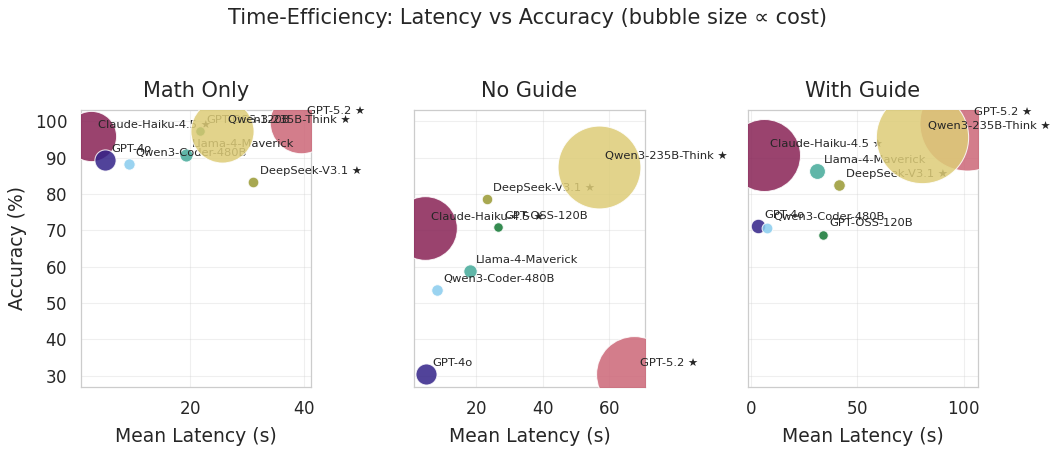

In [ ]:
# ── 13. Time-Efficiency Frontier: Latency vs Accuracy vs Dollar Cost ──
# Each model is a point: x=mean latency, y=accuracy, size=cost

eff = (
    df_time.groupby(['model', 'condition'])
    .agg(
        mean_latency=('call_seconds', 'mean'),
        accuracy=('is_correct', 'mean'),
        mean_cost=('cost_usd', 'mean'),
    )
    .reset_index()
)
eff['accuracy_%'] = eff['accuracy'] * 100

# Expected seconds per correct answer = mean_latency / accuracy
# (how long a user waits on average to get one correct answer)
eff['secs_per_correct'] = eff['mean_latency'] / eff['accuracy'].clip(lower=0.01)

cond_order = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5), sharey=True)

for ax, cond in zip(axes, cond_order):
    sub = eff[eff['condition'] == cond]
    for _, row in sub.iterrows():
        m = row['model']
        ax.scatter(row['mean_latency'], row['accuracy_%'],
                   s=row['mean_cost'] * 1e6 * 0.3 + 20,
                   color=MODEL_PALETTE.get(m, '#999'),
                   edgecolors='white', linewidths=0.5, alpha=0.85, zorder=3)
        ax.annotate(MODEL_DISPLAY.get(m, m), (row['mean_latency'], row['accuracy_%']),
                    fontsize=5.5, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Mean Latency (s)')
    ax.set_title(COND_LABELS.get(cond, cond))
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Accuracy (%)')
fig.suptitle('Time-Efficiency: Latency vs Accuracy (bubble size ∝ cost)', fontsize=10, y=1.03)
plt.tight_layout()
save_fig(fig, 'time_cost_efficiency_frontier')
plt.show()

=== Expected Seconds per Correct Answer ===
                    Avg Latency (s)  Accuracy  Wait/Correct (s)
display                                                        
GPT-4o                         4.09      0.67              6.08
Claude-Haiku-4.5 ★             5.17      0.82              6.34
Qwen3-Coder-480B               8.12      0.67             12.21
Llama-4-Maverick              25.46      0.77             32.94
DeepSeek-V3.1 ★               31.90      0.81             39.59
GPT-OSS-120B                  29.63      0.72             41.09
Qwen3-235B-Think ★            66.13      0.91             72.29
GPT-5.2 ★                     83.77      0.87             96.80
  → saved time_cost_wait_per_correct.pdf / .png


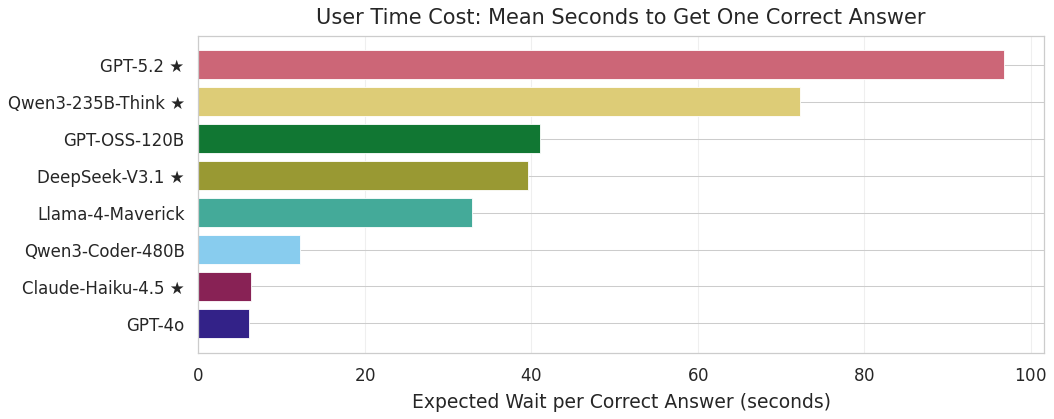


=== Wait per Correct Answer by Model × Condition ===
condition           in_domain_no_guide  in_domain_with_guide  math_only
model                                                                  
Claude-Haiku-4.5 ★                 6.5                   6.9        2.8
DeepSeek-V3.1 ★                   29.6                  50.6       37.4
GPT-4o                            16.0                   5.0        5.7
GPT-5.2 ★                        221.8                 102.3       39.6
GPT-OSS-120B                      37.5                  49.7       22.3
Llama-4-Maverick                  30.7                  36.2       21.2
Qwen3-Coder-480B                  15.6                  11.0       10.5
Qwen3-235B-Think ★                65.3                  84.2       26.3


In [23]:
# ── 14. Expected Wait per Correct Answer ──
# The "real" user cost: how many seconds do you wait, on average,
# to get ONE correct answer?  Penalises both slow and inaccurate models.

wait_per_correct = (
    df_time.groupby('model')
    .agg(mean_latency=('call_seconds', 'mean'), accuracy=('is_correct', 'mean'))
    .reset_index()
)
wait_per_correct['secs_per_correct'] = (
    wait_per_correct['mean_latency'] / wait_per_correct['accuracy'].clip(lower=0.001)
)
wait_per_correct['display'] = wait_per_correct['model'].map(MODEL_DISPLAY)
wait_per_correct = wait_per_correct.sort_values('secs_per_correct')

print("=== Expected Seconds per Correct Answer ===")
print(wait_per_correct.set_index('display')[
    ['mean_latency', 'accuracy', 'secs_per_correct']
].rename(columns={'mean_latency': 'Avg Latency (s)', 'accuracy': 'Accuracy',
                   'secs_per_correct': 'Wait/Correct (s)'}).round(2).to_string())

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
colors = [MODEL_PALETTE.get(m, '#999') for m in wait_per_correct['model']]
ax.barh(wait_per_correct['display'], wait_per_correct['secs_per_correct'],
        color=colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Expected Wait per Correct Answer (seconds)')
ax.set_title('User Time Cost: Mean Seconds to Get One Correct Answer')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'time_cost_wait_per_correct')
plt.show()

# ── Condition breakdown ──
wait_cond = (
    df_time.groupby(['model', 'condition'])
    .agg(mean_latency=('call_seconds', 'mean'), accuracy=('is_correct', 'mean'))
    .reset_index()
)
wait_cond['secs_per_correct'] = wait_cond['mean_latency'] / wait_cond['accuracy'].clip(lower=0.001)

print("\n=== Wait per Correct Answer by Model × Condition ===")
pivot_wait = wait_cond.pivot(index='model', columns='condition', values='secs_per_correct')
pivot_wait.index = pivot_wait.index.map(lambda m: MODEL_DISPLAY.get(m, m))
print(pivot_wait.round(1).to_string())

  → saved time_cost_dollar_vs_time.pdf / .png


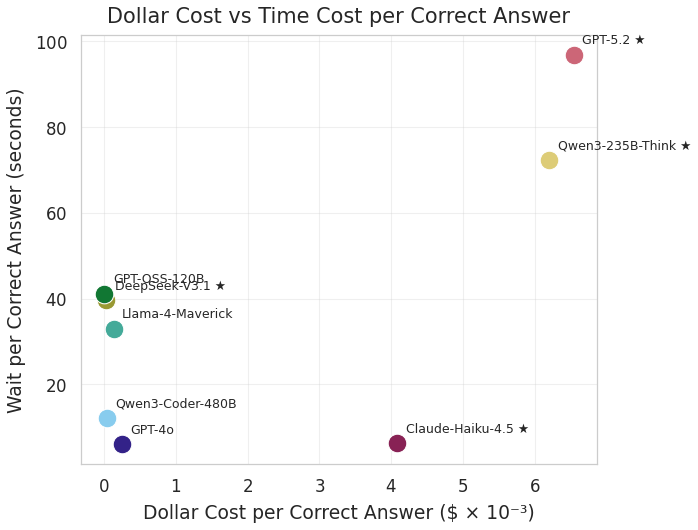

=== Dollar vs Time Cost Summary ===
                    $/Query  Latency(s)  Accuracy $/Correct  Secs/Correct
display                                                                  
GPT-4o              0.00016        4.09      0.67   0.00024          6.08
Claude-Haiku-4.5 ★  0.00333        5.17      0.82   0.00409          6.34
Qwen3-Coder-480B    0.00003        8.12      0.67   0.00004         12.21
Llama-4-Maverick    0.00010       25.46      0.77   0.00013         32.94
DeepSeek-V3.1 ★     0.00003       31.90      0.81   0.00003         39.59
GPT-OSS-120B        0.00000       29.63      0.72   0.00000         41.09
Qwen3-235B-Think ★  0.00567       66.13      0.91   0.00620         72.29
GPT-5.2 ★           0.00566       83.77      0.87   0.00654         96.80


In [ ]:
# ── 15. Dollar Cost vs Time Cost: Are They Correlated? ──
# A model can be cheap in dollars but expensive in time (or vice versa).

dollar_vs_time = (
    df_time.groupby('model')
    .agg(
        mean_cost_usd=('cost_usd', 'mean'),
        mean_latency=('call_seconds', 'mean'),
        accuracy=('is_correct', 'mean'),
    )
    .reset_index()
)
dollar_vs_time['cost_per_correct_usd'] = (
    dollar_vs_time['mean_cost_usd'] / dollar_vs_time['accuracy'].clip(lower=0.001)
)
dollar_vs_time['secs_per_correct'] = (
    dollar_vs_time['mean_latency'] / dollar_vs_time['accuracy'].clip(lower=0.001)
)

fig, ax = plt.subplots(figsize=(PAGE_W / 1.5, PAGE_W / GOLDEN / 1.2))
for _, row in dollar_vs_time.iterrows():
    m = row['model']
    ax.scatter(row['cost_per_correct_usd'] * 1000, row['secs_per_correct'],
               s=80, color=MODEL_PALETTE.get(m, '#999'),
               edgecolors='white', linewidths=0.5, zorder=3)
    ax.annotate(MODEL_DISPLAY.get(m, m), (row['cost_per_correct_usd'] * 1000, row['secs_per_correct']),
                fontsize=6, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Dollar Cost per Correct Answer ($ × 10⁻³)')
ax.set_ylabel('Wait per Correct Answer (seconds)')
ax.set_title('Dollar Cost vs Time Cost per Correct Answer')
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'time_cost_dollar_vs_time')
plt.show()

print("=== Dollar vs Time Cost Summary ===")
summary = dollar_vs_time.copy()
summary['display'] = summary['model'].map(MODEL_DISPLAY)
summary = summary.set_index('display')[
    ['mean_cost_usd', 'mean_latency', 'accuracy', 'cost_per_correct_usd', 'secs_per_correct']
].rename(columns={
    'mean_cost_usd': '$/Query', 'mean_latency': 'Latency(s)',
    'accuracy': 'Accuracy', 'cost_per_correct_usd': '$/Correct',
    'secs_per_correct': 'Secs/Correct'
})
summary['$/Query'] = summary['$/Query'].map('{:.5f}'.format)
summary['$/Correct'] = summary['$/Correct'].map('{:.5f}'.format)
print(summary.sort_values('Secs/Correct').round(2).to_string())